# 04 - Modeling (Grant Witness)

### Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install optuna catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 33.0 MB/s eta 0:00:00


In [ ]:
import os
import re
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold,
    cross_val_score, cross_validate
)
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, accuracy_score

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sentence_transformers import SentenceTransformer

import torch
from transformers import AutoTokenizer
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import clone
import spacy
import json as json

import re
import shap

import json as json

import optuna
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from tqdm.auto import tqdm as _tqdm

optuna.logging.set_verbosity(optuna.logging.WARNING)


In [ ]:
# df_all_common = pd.read_parquet('00_data/embeddings/nomic/df_full_with_embeddings_nomic.parquet')
df_all_common = pd.read_parquet('/content/drive/MyDrive/thesis/gw/03_full.parquet')


In [ ]:
df_all_common = df_all_common.drop_duplicates(subset='abstract')

In [ ]:
df_all_common

,abstract,abstract_embeddings_nomic,agency,avg_repetition,award_amount,award_outlaid,award_remaining,flagged_words_all_abstract,flagged_words_all_title,grant_id,...,total_pen_terms_title,unique_flagged_words_abstract,unique_flagged_words_title,unique_flagged_words_total,unique_nyt_words_abstract,unique_nyt_words_title,unique_pen_words_abstract,unique_pen_words_title,usaspending_url,target_adverse
0,None,"[0.013269751332700253, 0.015861643478274345, -...",NIH,0.000000,69867044.00,26075910.60,43791133.40,None,None,AY2AX000005,...,0,0,0,0,0,0,0,0,https://www.usaspending.gov/award/ASST_NON_AY2...,0
3,PROJECT SUMMARY This institutional grant propo...,"[0.019225066527724266, 0.1197880282998085, -0....",NIH,1.000000,8000000.00,8000000.00,0.00,institutional,institutional,C06OD030152,...,0,1,1,2,1,1,1,1,https://www.usaspending.gov/award/ASST_NON_C06...,0
4,Project Summary/Abstract Wards 7 and 8 in Wash...,"[0.0020422835368663073, 0.09004892408847809, -...",NIH,2.100000,2000000.00,618137.31,1381862.69,community; inequities; integration; marginaliz...,community,C06OD034040,...,0,9,1,10,6,0,8,1,https://www.usaspending.gov/award/ASST_NON_C06...,0
5,Project Summary The goal of the proposed HIV/...,"[-0.012400302104651928, 0.06091583892703056, -...",NIH,1.642857,113750.86,113750.86,0.00,barriers; bipoc; black; community; covid-19; h...,None,C06OD034042,...,0,14,0,14,9,0,14,0,https://www.usaspending.gov/award/ASST_NON_C06...,1
7,PROJECT SUMMARY The Northwestern University (N...,"[-0.0009703771211206913, 0.048112306743860245,...",NIH,0.000000,1302310.00,933861.02,368448.98,None,None,D43CA260658,...,0,0,0,0,0,0,0,0,https://www.usaspending.gov/award/ASST_NON_D43...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11403,The Gay and Lesbian Community Center of Southe...,"[-0.011459187604486942, 0.07353552430868149, -...",SAMHSA,1.266667,1399951.00,627976.17,771974.83,at risk; black; community; female; gay; gender...,minority,TI088031,...,0,14,1,15,10,1,14,1,https://www.usaspending.gov/award/ASST_NON_H79...,0
11404,The American Academy of Addiction Psychiatry (...,"[-0.020633738487958908, 0.03923909738659859, -...",SAMHSA,2.153846,37000000.00,9429793.33,27570206.67,black; community; continuum; culturally respon...,tribal,TI088037,...,0,12,1,13,8,1,12,1,https://www.usaspending.gov/award/ASST_NON_H79...,0
11405,"The Ali Forney Center (AFC), the largest provi...","[-0.02132534794509411, 0.06883826851844788, -0...",SAMHSA,1.538462,1399980.00,358000.00,1041980.00,bipoc; bisexual; black; gay; indigenous; lesbi...,minority,TI088051,...,0,12,1,13,8,1,12,1,https://www.usaspending.gov/award/ASST_NON_H79...,0
11406,In response to the U.S. Department of Health a...,"[0.0075111594051122665, 0.027737023308873177, ...",SAMHSA,1.789474,1400000.00,406761.00,993239.00,at risk; bisexual; black; community; culturall...,minority,TI088072,...,0,18,1,19,13,1,18,1,https://www.usaspending.gov/award/ASST_NON_H79...,0


Target variable

In [ ]:
df_all_common.columns

Index(['abstract', 'abstract_embeddings_nomic', 'agency', 'avg_repetition',
       'award_amount', 'award_outlaid', 'award_remaining',
       'flagged_words_all_abstract', 'flagged_words_all_title', 'grant_id',
       'has_flagged_terms_total', 'has_flagged_word_total', 'org_city',
       'org_name', 'org_state', 'project_title', 'reinstatement_date',
       'reinstatement_indicator', 'start_date_original', 'status',
       'termination_date', 'title_embeddings_nomic',
       'total_flagged_terms_abstract', 'total_flagged_terms_title',
       'total_flagged_terms_total', 'total_nyt_terms_abstract',
       'total_nyt_terms_title', 'total_pen_terms_abstract',
       'total_pen_terms_title', 'unique_flagged_words_abstract',
       'unique_flagged_words_title', 'unique_flagged_words_total',
       'unique_nyt_words_abstract', 'unique_nyt_words_title',
       'unique_pen_words_abstract', 'unique_pen_words_title',
       'usaspending_url', 'target_adverse'],
      dtype='object')

In [ ]:
df_all_common.groupby("target_adverse")[["total_flagged_terms_total", "total_pen_terms_abstract", "total_nyt_terms_abstract", "total_flagged_terms_title"]].mean()

,total_flagged_terms_total,total_pen_terms_abstract,total_nyt_terms_abstract,total_flagged_terms_title
target_adverse,,,,
0,10.467476,6.159105,4.210479,0.097891
1,13.929739,7.620174,6.163130,0.146435


In [ ]:
target = ['target_adverse']

#### Feature engineering

In [ ]:
df_all_common['log_total_award'] = np.log1p(df_all_common['award_amount'])
df_all_common['all_text'] = df_all_common['project_title'].fillna('') + ' ' + df_all_common['abstract'].fillna('')
df_all_common['start_year'] = pd.to_datetime(df_all_common['start_date_original'], errors='coerce').dt.year

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


text properties

In [ ]:
df_all_common['text_len'] = df_all_common['all_text'].str.split().str.len()
df_all_common['abstract_len'] = df_all_common['abstract'].fillna('').str.len()
df_all_common['title_len'] = df_all_common['project_title'].fillna('').str.len()
df_all_common['abstract_word_count'] = df_all_common['abstract'].fillna('').str.split().str.len()

keyword risk

In [ ]:
df_all_common['avg_repetition'] = (df_all_common['total_flagged_terms_total'] / df_all_common['unique_flagged_words_total'].replace(0, np.nan)).fillna(1.0)
df_all_common['flagged_ratio'] = (df_all_common['total_flagged_terms_total'] / df_all_common['text_len'].replace(0, np.nan)).fillna(0)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# All Data

In [ ]:
df_split = df_all_common.dropna(subset=['target_adverse'])
train_idx, test_idx = train_test_split(df_split.index, test_size=0.2, random_state=42, stratify=df_split['target_adverse'])

df_train = df_all_common.loc[train_idx]
df_test = df_all_common.loc[test_idx]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Train {len(df_train):,}, Test (held-out) {len(df_test):,}")


Train 8,560, Test (held-out) 2,140


# SRQ1: Baselines

In [ ]:
def make_lr_variants(max_iter):
    Cs = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]

    def make_gscv(solver, l1_ratio=0.0):
        kwargs = {'l1_ratio': l1_ratio} if l1_ratio else {}
        return GridSearchCV(
            LogisticRegression(solver=solver, max_iter=max_iter, class_weight='balanced', **kwargs),
            param_grid={'C': Cs}, scoring='average_precision', cv=5, n_jobs=-1, refit=True,
        )

    return {
        'LR-L2':    lambda: LogisticRegression(solver='lbfgs', max_iter=max_iter, class_weight='balanced'),
        'LR-L1':    lambda: LogisticRegression(l1_ratio=1.0, solver='liblinear', max_iter=max_iter, class_weight='balanced'),
        'LR-CV-L2': lambda: make_gscv('lbfgs'),
        'LR-CV-L1': lambda: make_gscv('liblinear', l1_ratio=1.0),
    }

def get_best_c(clf):
    if hasattr(clf, 'best_params_'):
        return clf.best_params_['C']
    return None

def make_ratio_df(df):
    d = df.copy()
    d['flagged_ratio'] = d['num_flagged_words_total'] / d['text_len'].replace(0, np.nan)
    return d.dropna(subset=['flagged_ratio', 'target_adverse'])

def make_embed_matrix(df):
    d = df.dropna(subset=embed_cols + ['target_adverse'])
    def parse(series):
        return np.vstack(series.apply(
            lambda x: np.fromstring(str(x).replace('\n', ' ').strip()[1:-1],
                                    sep=' ', dtype=np.float32)
        ).values)
    X = np.hstack([parse(d[embed_cols[0]]), parse(d[embed_cols[1]])])
    y = d['target_adverse'].values
    return X, y

def num_preprocessor(num_cols):
    log_c = [c for c in num_cols if c in log_cols]
    std_c = [c for c in num_cols if c in std_cols]
    bin_c = [c for c in num_cols if c in bin_cols]
    parts = []
    if log_c:
        parts.append(('log_num', make_pipeline(SimpleImputer(strategy='median'), FunctionTransformer(np.log1p, feature_names_out='one-to-one'), StandardScaler()), log_c))
    if std_c:
        parts.append(('std_num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), std_c))
    if bin_c:
        parts.append(('bin_num', SimpleImputer(strategy='most_frequent'), bin_c))
    return parts

def parse_embed_matrix(df):
    return np.hstack([np.vstack(df[col].tolist()) for col in embed_cols])

def make_embed_matrix(df):
    df_clean = df.dropna(subset=embed_cols + ['target_adverse'])
    X = parse_embed_matrix(df_clean)
    y = df_clean['target_adverse'].values
    return X, y
def make_lr_variants(max_iter):
    Cs = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]

    def make_gscv(solver, l1_ratio=0.0):
        kwargs = {'l1_ratio': l1_ratio} if l1_ratio else {}
        return GridSearchCV(
            LogisticRegression(solver=solver, max_iter=max_iter, class_weight='balanced', **kwargs),
            param_grid={'C': Cs}, scoring='average_precision', cv=5, n_jobs=-1, refit=True,
        )

    return {
        'LR-L2':    lambda: LogisticRegression(solver='lbfgs', max_iter=max_iter, class_weight='balanced'),
        'LR-L1':    lambda: LogisticRegression(l1_ratio=1.0, solver='liblinear', max_iter=max_iter, class_weight='balanced'),
        'LR-CV-L2': lambda: make_gscv('lbfgs'),
        'LR-CV-L1': lambda: make_gscv('liblinear', l1_ratio=1.0),
    }

def get_best_c(clf):
    if hasattr(clf, 'best_params_'):
        return clf.best_params_['C']
    return None

def make_ratio_df(df):
    d = df.copy()
    d['flagged_ratio'] = d['num_flagged_words_total'] / d['text_len'].replace(0, np.nan)
    return d.dropna(subset=['flagged_ratio', 'target_adverse'])

def make_embed_matrix(df):
    d = df.dropna(subset=embed_cols + ['target_adverse'])
    def parse(series):
        return np.vstack(series.apply(
            lambda x: np.fromstring(str(x).replace('\n', ' ').strip()[1:-1],
                                    sep=' ', dtype=np.float32)
        ).values)
    X = np.hstack([parse(d[embed_cols[0]]), parse(d[embed_cols[1]])])
    y = d['target_adverse'].values
    return X, y

def num_preprocessor(num_cols):
    log_c = [c for c in num_cols if c in log_cols]
    std_c = [c for c in num_cols if c in std_cols]
    bin_c = [c for c in num_cols if c in bin_cols]
    parts = []
    if log_c:
        parts.append(('log_num', make_pipeline(SimpleImputer(strategy='median'), FunctionTransformer(np.log1p, feature_names_out='one-to-one'), StandardScaler()), log_c))
    if std_c:
        parts.append(('std_num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), std_c))
    if bin_c:
        parts.append(('bin_num', SimpleImputer(strategy='most_frequent'), bin_c))
    return parts

def parse_embed_matrix(df):
    return np.hstack([np.vstack(df[col].tolist()) for col in embed_cols])

def make_embed_matrix(df):
    df_clean = df.dropna(subset=embed_cols + ['target_adverse'])
    X = parse_embed_matrix(df_clean)
    y = df_clean['target_adverse'].values
    return X, y


## 1. Majority class

In [ ]:
df_b1_train = df_train.dropna(subset=["target_adverse"])
df_b1_test = df_test.dropna(subset=["target_adverse"])
X_b1_train = pd.DataFrame(np.zeros(len(df_b1_train)), index=df_b1_train.index)
y_b1_train = df_b1_train["target_adverse"]
X_b1_test = pd.DataFrame(np.zeros(len(df_b1_test)), index=df_b1_test.index)
y_b1_test = df_b1_test["target_adverse"]

In [94]:
dummy = DummyClassifier(strategy='most_frequent')
cv_b1 = cross_validate(dummy, X_b1_train, y_b1_train, cv=skf, scoring=['roc_auc', 'average_precision', 'accuracy'], return_train_score=True)

print(f"cv roc auc {cv_b1['test_roc_auc'].mean():.4f} \u00b1 {cv_b1['test_roc_auc'].std():.4f}")
print(f"cv auc pr {cv_b1['test_average_precision'].mean():.4f} \u00b1 {cv_b1['test_average_precision'].std():.4f}")
print(f"cv accuracy {cv_b1['test_accuracy'].mean():.4f} \u00b1 {cv_b1['test_accuracy'].std():.4f}")

cv roc auc 0.5000 ± 0.0000
cv auc pr 0.2687 ± 0.0000
cv accuracy 0.7313 ± 0.0000


In [95]:
dummy.fit(X_b1_train, y_b1_train)
y_prob = dummy.predict_proba(X_b1_test)[:, 1]
test_auc = roc_auc_score(y_b1_test, y_prob)
test_aucpr = average_precision_score(y_b1_test, y_prob)

print(f"test roc auc {test_auc:.4f}")
print(f"test auc pr {test_aucpr:.4f}")
print(f"test accuracy: {accuracy_score(y_b1_test, dummy.predict(X_b1_test)):.4f}")

test roc auc 0.5000
test auc pr 0.2687
test accuracy: 0.7313


## 2. Keyword count

In [96]:
df_b2_train = df_train.dropna(subset=["flagged_ratio", "target_adverse"])
df_b2_test = df_test.dropna(subset=["flagged_ratio", "target_adverse"])
X_b2_train = df_b2_train[["flagged_ratio"]]
y_b2_train = df_b2_train["target_adverse"]
X_b2_test = df_b2_test[["flagged_ratio"]]
y_b2_test = df_b2_test["target_adverse"]


In [97]:
for name, clf_fn in make_lr_variants(1000).items():
    clf = clf_fn()
    cv = cross_validate(clf, X_b2_train, y_b2_train, cv=skf, scoring=['roc_auc', 'average_precision', 'accuracy'], return_train_score=True)
    clf = clf_fn()
    clf.fit(X_b2_train, y_b2_train)
    y_prob = clf.predict_proba(X_b2_test)[:, 1]
    test_auc = roc_auc_score(y_b2_test, y_prob)
    test_aucpr = average_precision_score(y_b2_test, y_prob)

    print(name)
    print(f"cv roc auc {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}")
    print(f"cv auc pr {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}")
    print(f"test roc auc {test_auc:.4f}, test auc pr {test_aucpr:.4f}")

    best_c = get_best_c(clf)
    if best_c: print(f"best c {best_c:.4f}")
    print()


LR-L2
cv roc auc 0.5217 ± 0.0080
cv auc pr 0.3321 ± 0.0112
test roc auc 0.5227, test auc pr 0.3411

LR-L1
cv roc auc 0.5217 ± 0.0080
cv auc pr 0.3321 ± 0.0112
test roc auc 0.5227, test auc pr 0.3411



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

LR-CV-L2
cv roc auc 0.5217 ± 0.0080
cv auc pr 0.3321 ± 0.0112
test roc auc 0.5227, test auc pr 0.3411
best c 0.0010



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


LR-CV-L1
cv roc auc 0.5217 ± 0.0080
cv auc pr 0.3321 ± 0.0112
test roc auc 0.5227, test auc pr 0.3411
best c 0.0010



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


## 3. TF-IDF + logistic regression

In [98]:
df_b3_train = df_train.dropna(subset=['all_text', 'target_adverse'])
df_b3_test = df_test.dropna(subset=['all_text', 'target_adverse'])
X_b3_train = df_b3_train['all_text']
y_b3_train = df_b3_train['target_adverse']
X_b3_test = df_b3_test['all_text']
y_b3_test = df_b3_test['target_adverse']

To select max_features:

In [ ]:
vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
vec.fit(X_b3_train)
print(len(vec.vocabulary_))  # total unique terms

977014


In [ ]:
candidates = [1_000, 2_500, 5_000, 10_000, 25_000, 50_000]
aucs = []
for n in candidates:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=n, ngram_range=(1, 2), sublinear_tf=True)),
        ('lr',    LogisticRegression(max_iter=1000, class_weight='balanced')),
    ])
    score = cross_val_score(pipe, X_b3_train, y_b3_train, cv=skf, scoring='roc_auc').mean()
    aucs.append(score)
    print(f"{n:>6,}  AUC={score:.4f}")

plt.plot(candidates, aucs, marker='o')
plt.xscale('log')
plt.xlabel('max_features')
plt.ylabel('ROC AUC')
plt.title('TF-IDF vocab size vs. AUC')
plt.show()


 1,000  AUC=0.8714


In [99]:
for name, clf_fn in make_lr_variants(1000).items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                                  sublinear_tf=True, stop_words='english')),
        ('lr', clf_fn()),
    ])
    cv = cross_validate(pipe, X_b3_train, y_b3_train, cv=skf, scoring=['roc_auc', 'average_precision', 'accuracy'], return_train_score=True)

    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                                  sublinear_tf=True, stop_words='english')),
        ('lr', clf_fn()),
    ])
    pipe.fit(X_b3_train, y_b3_train)
    y_prob = pipe.predict_proba(X_b3_test)[:, 1]
    test_auc = roc_auc_score(y_b3_test, y_prob)
    test_aucpr = average_precision_score(y_b3_test, y_prob)

    print(name)
    print(f"cv roc auc {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}")
    print(f"cv auc pr {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}")
    print(f"test roc auc {test_auc:.4f}, test auc pr {test_aucpr:.4f}")

    best_c = get_best_c(pipe['lr'])
    if best_c is not None: print(f"best c {best_c:.4f}")
    print()

LR-L2
cv roc auc 0.8967 ± 0.0049
cv auc pr 0.8035 ± 0.0094
test roc auc 0.9096, test auc pr 0.8327



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

LR-L1
cv roc auc 0.8968 ± 0.0049
cv auc pr 0.8038 ± 0.0094
test roc auc 0.9092, test auc pr 0.8317

LR-CV-L2
cv roc auc 0.8990 ± 0.0070
cv auc pr 0.8081 ± 0.0119
test roc auc 0.9119, test auc pr 0.8371
best c 2.0000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

LR-CV-L1
cv roc auc 0.8989 ± 0.0070
cv auc pr 0.8081 ± 0.0120
test roc auc 0.9119, test auc pr 0.8367
best c 2.0000



In [100]:
pipe_best = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                              sublinear_tf=True, stop_words='english')),
    ('lr', make_lr_variants(1000)['LR-CV-L2']()),
])
pipe_best.fit(X_b3_train, y_b3_train)
vec, coefs = pipe_best['tfidf'], pipe_best['lr'].best_estimator_.coef_[0]
pd.DataFrame({'term': vec.get_feature_names_out(), 'coefficient': coefs}).sort_values('coefficient', ascending=False).head(20)


,term,coefficient
2835,duke,5.149852
8924,supplement,3.557796
561,agreement,2.885845
3770,gender,2.693295
6420,parent,2.606609
5693,misinformation,2.584452
3160,environmental,2.522763
5043,lab,2.489715
1194,black,2.463424
3206,equity,2.449851


## 4. Sentence embeddings + logistic regression

In [ ]:
embed_cols = ['abstract_embeddings_nomic', 'title_embeddings_nomic']

X_b4_train, y_b4_train = make_embed_matrix(df_train)
X_b4_test,  y_b4_test = make_embed_matrix(df_test)


In [101]:
for name, clf_fn in make_lr_variants(5000).items():
    clf = clf_fn()
    cv = cross_validate(clf, X_b4_train, y_b4_train, cv=skf, scoring=['roc_auc', 'average_precision', 'accuracy'], return_train_score=True)
    clf = clf_fn()
    clf.fit(X_b4_train, y_b4_train)
    y_prob = clf.predict_proba(X_b4_test)[:, 1]


    test_auc = roc_auc_score(y_b4_test, y_prob)
    test_aucpr = average_precision_score(y_b4_test, y_prob)

    print(name)
    print(f"cv roc auc {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}")
    print(f"cv auc pr {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}")
    print(f"test roc auc {test_auc:.4f}, test auc pr {test_aucpr:.4f}")

    best_c = get_best_c(clf)
    if best_c is not None: print(f"best c {best_c:.4f}")
    print()


LR-L2
cv roc auc 0.8801 ± 0.0070
cv auc pr 0.7828 ± 0.0129
test roc auc 0.8985, test auc pr 0.8102



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

LR-L1
cv roc auc 0.8801 ± 0.0068
cv auc pr 0.7825 ± 0.0131
test roc auc 0.8980, test auc pr 0.8102

LR-CV-L2
cv roc auc 0.8812 ± 0.0067
cv auc pr 0.7848 ± 0.0122
test roc auc 0.9003, test auc pr 0.8112
best c 2.0000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

LR-CV-L1
cv roc auc 0.8820 ± 0.0072
cv auc pr 0.7859 ± 0.0131
test roc auc 0.9005, test auc pr 0.8122
best c 2.0000



## SRQ2: Metadata

In [ ]:
financial = ['award_amount',
             'award_outlaid',
             'award_remaining',
             'log_total_award']

keyword = ['total_flagged_terms_total',
           'total_flagged_terms_title',
           'has_flagged_terms_total',
          #  'flagged_words_all_title',
           'total_nyt_terms_abstract',
           'total_nyt_terms_title',
           'total_pen_terms_abstract',
           'total_pen_terms_title',
          #  'unique_flagged_words_abstract',
           'avg_repetition',
           'flagged_ratio']

temporal = ['start_year']

text_props = ['text_len',
              'abstract_len',
              'title_len',
              'abstract_word_count']

inst_cat = ['org_state']

num_cols = (
    financial +
    keyword +
    temporal +
    text_props
)

num_cols = list(dict.fromkeys(num_cols))
cat_cols = inst_cat

all_cols = num_cols + cat_cols

In [ ]:
log_cols = frozenset([
    'award_amount',
    'num_flagged_words_total',
    'unique_flagged_words_total',
    'total_nyt_terms_title',
    'total_nyt_terms_abstract',
    'total_pen_terms_title',
    'total_pen_terms_abstract',
    'text_len',
    'abstract_len',
    'title_len',
    'abstract_word_count',
    'flagged_ratio',
    'total_flagged_terms_total',
    'total_flagged_terms_title',
    'has_flagged_terms_total',
    # 'flagged_words_all_title',
    # 'unique_flagged_words_abstract',
])

std_cols = frozenset(['log_total_award', 'start_year', 'avg_repetition',
                       'award_outlaid', 'award_remaining'])
bin_cols = frozenset(['has_flagged_word_total'])

### 5.1 Metadata

In [ ]:
df_train['start_year'] = pd.to_datetime(df_train['start_date_original'], errors='coerce').dt.year
df_test['start_year']  = pd.to_datetime(df_test['start_date_original'],  errors='coerce').dt.year

In [ ]:
df_b5_train = df_train.dropna(subset=all_cols + ['target_adverse'])
df_b5_test = df_test.dropna(subset=all_cols  + ['target_adverse'])
X_b5_train = df_b5_train[all_cols]
y_b5_train = df_b5_train['target_adverse']
X_b5_test = df_b5_test[all_cols]
y_b5_test = df_b5_test['target_adverse']

In [ ]:
pre_b5 = ColumnTransformer(num_preprocessor(num_cols) + [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)], remainder='drop')

In [ ]:
for name, clf_fn in make_lr_variants(10_000).items():
    pipe = Pipeline([('pre', pre_b5), ('clf', clf_fn())])
    cv = cross_validate(pipe, X_b5_train, y_b5_train, cv=skf, scoring=['roc_auc', 'average_precision', 'accuracy'], return_train_score=True)
    pipe = Pipeline([('pre', pre_b5), ('clf', clf_fn())])
    pipe.fit(X_b5_train, y_b5_train)
    y_prob = pipe.predict_proba(X_b5_test)[:, 1]
    test_auc = roc_auc_score(y_b5_test, y_prob)
    test_aucpr = average_precision_score(y_b5_test, y_prob)

    print(name)
    print(f"cv roc auc {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}")
    print(f"cv auc pr {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}")
    print(f"test roc auc {test_auc:.4f}, test auc pr {test_aucpr:.4f}")

    best_c = get_best_c(pipe['clf'])
    if best_c is not None: print(f"best c {best_c:.4f}")
    print()

lrcv_pipe = Pipeline([('pre', pre_b5), ('clf', make_lr_variants(10_000)['LR-CV-L2']())])
lrcv_pipe.fit(X_b5_train, y_b5_train)
feature_names = [n.split("__", 1)[-1] for n in lrcv_pipe["pre"].get_feature_names_out()]
pd.DataFrame({
    'feature': feature_names,
    'coefficient': lrcv_pipe['clf'].best_estimator_.coef_[0],
}).sort_values('coefficient', ascending=False)


LR-L2
cv roc auc 0.9302 ± 0.0080
cv auc pr 0.7330 ± 0.0209
test roc auc 0.9314, test auc pr 0.7446



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

LR-L1
cv roc auc 0.9302 ± 0.0080
cv auc pr 0.7333 ± 0.0208
test roc auc 0.9314, test auc pr 0.7448

LR-CV-L2
cv roc auc 0.9300 ± 0.0084
cv auc pr 0.7326 ± 0.0232
test roc auc 0.9306, test auc pr 0.7439
best c 0.5000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

LR-CV-L1
cv roc auc 0.9300 ± 0.0084
cv auc pr 0.7331 ± 0.0232
test roc auc 0.9305, test auc pr 0.7440
best c 0.5000



,feature,coefficient
50,org_state_NC,5.113573
10,abstract_len,4.967468
26,org_state_DC,1.615081
70,org_state_VA,1.514786
4,total_nyt_terms_abstract,1.153212
...,...,...
41,org_state_MA,-1.312917
64,org_state_RI,-1.454931
23,org_state_CA,-1.491007
12,abstract_word_count,-1.899798


In [ ]:
lrcv_pipe = Pipeline([('pre', pre_b5), ('clf', make_lr_variants(10_000)['LR-CV-L2']())])
lrcv_pipe.fit(X_b5_train, y_b5_train)
feature_names = [n.split("__", 1)[-1] for n in lrcv_pipe["pre"].get_feature_names_out()]
pd.DataFrame({'feature': feature_names, 'coefficient': lrcv_pipe['clf'].best_estimator_.coef_[0]}).sort_values('coefficient', ascending=False)

,feature,coefficient
50,org_state_NC,5.113573
10,abstract_len,4.967468
26,org_state_DC,1.615081
70,org_state_VA,1.514786
4,total_nyt_terms_abstract,1.153212
...,...,...
41,org_state_MA,-1.312917
64,org_state_RI,-1.454931
23,org_state_CA,-1.491007
12,abstract_word_count,-1.899798


### 5.2 Metadata without org_state

In [ ]:
all_cols = num_cols

df_b5_train = df_train.dropna(subset=all_cols + ["target_adverse"])
df_b5_test = df_test.dropna(subset=all_cols  + ["target_adverse"])
X_b5_train = df_b5_train[all_cols]
y_b5_train = df_b5_train["target_adverse"]
X_b5_test = df_b5_test[all_cols]
y_b5_test = df_b5_test["target_adverse"]


In [ ]:
pre_b5 = ColumnTransformer(num_preprocessor(num_cols), remainder='drop')

In [ ]:
for name, clf_fn in make_lr_variants(10_000).items():
    pipe = Pipeline([('pre', pre_b5), ('clf', clf_fn())])
    cv = cross_validate(pipe, X_b5_train, y_b5_train, cv=skf, scoring=['roc_auc', 'average_precision', 'accuracy'], return_train_score=True)

    pipe = Pipeline([('pre', pre_b5), ('clf', clf_fn())])
    pipe.fit(X_b5_train, y_b5_train)
    y_prob = pipe.predict_proba(X_b5_test)[:, 1]
    test_auc = roc_auc_score(y_b5_test, y_prob)
    test_aucpr = average_precision_score(y_b5_test, y_prob)

    print(name)
    print(f"cv roc auc {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}")
    print(f"cv auc pr {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}")
    print(f"test roc auc {test_auc:.4f}, test auc pr {test_aucpr:.4f}")

    best_c = get_best_c(pipe['clf'])
    if best_c is not None: print(f"best c {best_c:.4f}")
    print()

LR-L2
cv roc auc 0.8497 ± 0.0050
cv auc pr 0.6452 ± 0.0072
test roc auc 0.8768, test auc pr 0.6979

LR-L1
cv roc auc 0.8498 ± 0.0050
cv auc pr 0.6453 ± 0.0073
test roc auc 0.8769, test auc pr 0.6976



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

LR-CV-L2
cv roc auc 0.8471 ± 0.0063
cv auc pr 0.6501 ± 0.0089
test roc auc 0.8700, test auc pr 0.7001
best c 0.1000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


LR-CV-L1
cv roc auc 0.8471 ± 0.0063
cv auc pr 0.6500 ± 0.0088
test roc auc 0.8700, test auc pr 0.7002
best c 0.1000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


In [ ]:
lrcv_pipe = Pipeline([("pre", pre_b5), ("clf", make_lr_variants(10_000)["LR-CV-L2"]())])
lrcv_pipe.fit(X_b5_train, y_b5_train)
feature_names = [n.split("__", 1)[-1] for n in lrcv_pipe["pre"].get_feature_names_out()]
pd.DataFrame({"feature": feature_names, "coefficient": lrcv_pipe["clf"].best_estimator_.coef_[0]}).sort_values("coefficient", ascending=False)


,feature,coefficient
10,abstract_len,2.799754
4,total_nyt_terms_abstract,1.008467
11,title_len,0.451863
8,flagged_ratio,0.250760
14,award_remaining,0.233351
1,total_flagged_terms_total,0.073077
7,total_pen_terms_title,0.071187
2,total_flagged_terms_title,0.022327
3,has_flagged_terms_total,0.021348
5,total_nyt_terms_title,-0.040014


### Feature ablation

In [ ]:
df_all_common.columns

Index(['abstract', 'abstract_embeddings_nomic', 'agency', 'avg_repetition',
       'award_amount', 'award_outlaid', 'award_remaining',
       'flagged_words_all_abstract', 'flagged_words_all_title', 'grant_id',
       'has_flagged_terms_total', 'has_flagged_word_total', 'org_city',
       'org_name', 'org_state', 'project_title', 'reinstatement_date',
       'reinstatement_indicator', 'start_date_original', 'status',
       'termination_date', 'title_embeddings_nomic',
       'total_flagged_terms_abstract', 'total_flagged_terms_title',
       'total_flagged_terms_total', 'total_nyt_terms_abstract',
       'total_nyt_terms_title', 'total_pen_terms_abstract',
       'total_pen_terms_title', 'unique_flagged_words_abstract',
       'unique_flagged_words_title', 'unique_flagged_words_total',
       'unique_nyt_words_abstract', 'unique_nyt_words_title',
       'unique_pen_words_abstract', 'unique_pen_words_title',
       'usaspending_url', 'target_adverse', 'log_total_award', 'all_text',
   

In [ ]:
# financial_cols = ['award_amount', 'award_outlaid', 'award_remaining', 'log_total_award']
# keyword_cols = [
#     'total_flagged_terms_total',
#     'unique_flagged_words_total',
#     'total_pen_terms_title',
#     'total_pen_terms_abstract',
#     'total_nyt_terms_title',
#     'total_nyt_terms_abstract',
#     'has_flagged_word_total',
#     'avg_repetition',
#     'flagged_ratio',
# ]
# temporal_cols = ['start_year']
# text_prop_cols = ['text_len', 'abstract_len', 'title_len', 'abstract_word_count']
# institutional_cats = ['org_state', 'agency']

In [ ]:
financial = ['award_amount',
             'award_outlaid',
             'award_remaining',
             'log_total_award']

keyword = ['total_flagged_terms_total',
           'total_flagged_terms_title',
           'has_flagged_terms_total',
          #  'flagged_words_all_title',
           'total_nyt_terms_abstract',
           'total_nyt_terms_title',
           'total_pen_terms_abstract',
           'total_pen_terms_title',
          #  'unique_flagged_words_abstract',
           'avg_repetition',
           'flagged_ratio']

temporal = ['start_year']

text_props = ['text_len',
              'abstract_len',
              'title_len',
              'abstract_word_count']

inst_cat = ['org_state']

num_cols = (
    financial +
    keyword +
    temporal +
    text_props
)

num_cols = list(dict.fromkeys(num_cols))
cat_cols = inst_cat

all_cols = num_cols + cat_cols

In [102]:
ablation_conditions = {
    'text only': ([], []),
    'text + financial': (financial, []),
    'text + keyword risk': (keyword, []),
    'text + temporal': (temporal, []),
    'text + institutional': ([], inst_cat),
    'text + text properties':(text_props, []),
    'text + all metadata': (financial + keyword + temporal + text_props,
                              inst_cat),
}

using embed cols too so that tf idf and embeddings are on the same rows

In [103]:
req_abl = (financial + keyword + temporal + text_props + inst_cat + ['abstract', 'all_text', 'target_adverse'])
df_abl_train = df_train.dropna(subset=req_abl)
df_abl_test = df_test.dropna(subset=req_abl)

print(f"train {len(df_abl_train):,}, test {len(df_abl_test):,}")


train 5,761, test 1,431


In [104]:
for name, df in [('train', df_abl_train), ('test', df_abl_test)]:
    counts = df['target_adverse'].value_counts()
    print(f"{name} {counts.to_dict()}, positive rate {df['target_adverse'].mean():.3f}")

train {0: 4736, 1: 1025}, positive rate 0.178
test {0: 1183, 1: 248}, positive rate 0.173


In [106]:
def make_ablation_pipeline(num_cols, cat_cols, include_text=True):
    transformers = []
    if include_text:
        transformers.append(
            ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                                      sublinear_tf=True, stop_words='english'), 'all_text')
        )
    if num_cols:
        transformers.extend(num_preprocessor(num_cols))
    if cat_cols:
        transformers.append(
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        )
    pre = ColumnTransformer(transformers, remainder='drop', sparse_threshold=0)
    return Pipeline([
        ('pre', pre),
        ('lr',  LogisticRegression(penalty='l2', solver='lbfgs',
                                   max_iter=5000, class_weight='balanced')),
    ])

input_cols = ['all_text'] + financial + keyword + temporal + text_props + inst_cat

all_meta_num = financial + keyword + temporal + text_props
all_meta_cat = inst_cat

#### TF iDF + metadata

In [107]:
ablation_runs = list(ablation_conditions.items()) + [
    ('Metadata only', (all_meta_num, all_meta_cat, False)),
]

In [108]:
abl_results = []
for item in ablation_runs:
    cond_name, args = item
    if len(args) == 3:
        num_cols, cat_cols, include_text = args
    else:
        num_cols, cat_cols = args
        include_text = True

    pipe = make_ablation_pipeline(num_cols, cat_cols, include_text=include_text)
    X_tr = df_abl_train[input_cols]
    X_te = df_abl_test[input_cols]
    y_tr = df_abl_train['target_adverse']
    y_te = df_abl_test['target_adverse']

    cv = cross_validate(pipe, X_tr, y_tr, cv=skf, scoring=['roc_auc', 'average_precision'], return_train_score=False)
    pipe.fit(X_tr, y_tr)
    y_prob = pipe.predict_proba(X_te)[:, 1]
    test_aucpr = average_precision_score(y_te, y_prob)
    test_auc = roc_auc_score(y_te, y_prob)

    abl_results.append({
        'condition': cond_name,
        'cv_aucpr': f"{cv['test_average_precision'].mean():.4f} \u00b1 {cv['test_average_precision'].std():.4f}",
        'test_aucpr': round(test_aucpr, 4),
        'cv_auc': f"{cv['test_roc_auc'].mean():.4f} \u00b1 {cv['test_roc_auc'].std():.4f}",
        'test_auc': round(test_auc, 4),
    })
    print(f"{cond_name:<30}  cv auc pr {cv['test_average_precision'].mean():.4f}  test auc pr {test_aucpr:.4f}  test ROC-AUC {test_auc:.4f}")

df_ablation = pd.DataFrame(abl_results).set_index('condition')
df_ablation

text only                       cv auc pr 0.8770  test auc pr 0.8955  test ROC-AUC 0.9675
text + financial                cv auc pr 0.8772  test auc pr 0.8985  test ROC-AUC 0.9688
text + keyword risk             cv auc pr 0.8823  test auc pr 0.8949  test ROC-AUC 0.9670
text + temporal                 cv auc pr 0.8759  test auc pr 0.8948  test ROC-AUC 0.9675
text + institutional            cv auc pr 0.9615  test auc pr 0.9732  test ROC-AUC 0.9917
text + text properties          cv auc pr 0.8767  test auc pr 0.8955  test ROC-AUC 0.9671
text + all metadata             cv auc pr 0.9636  test auc pr 0.9734  test ROC-AUC 0.9899
Metadata only                   cv auc pr 0.7330  test auc pr 0.7446  test ROC-AUC 0.9314


,cv_aucpr,test_aucpr,cv_auc,test_auc
condition,,,,
text only,0.8770 ± 0.0076,0.8955,0.9609 ± 0.0037,0.9675
text + financial,0.8772 ± 0.0045,0.8985,0.9623 ± 0.0025,0.9688
text + keyword risk,0.8823 ± 0.0082,0.8949,0.9583 ± 0.0053,0.9670
text + temporal,0.8759 ± 0.0076,0.8948,0.9608 ± 0.0033,0.9675
text + institutional,0.9615 ± 0.0136,0.9732,0.9897 ± 0.0046,0.9917
text + text properties,0.8767 ± 0.0077,0.8955,0.9601 ± 0.0034,0.9671
text + all metadata,0.9636 ± 0.0107,0.9734,0.9913 ± 0.0034,0.9899
Metadata only,0.7330 ± 0.0209,0.7446,0.9302 ± 0.0080,0.9314


#### TF IDF + metadata (excl. org_state)

In [109]:
ablation_runs = list(ablation_conditions.items()) + [
    ('Metadata only', (all_meta_num, [], False)),
]

In [110]:
abl_results = []
for item in ablation_runs:
    cond_name, args = item
    if len(args) == 3:
        num_cols, cat_cols, include_text = args
    else:
        num_cols, cat_cols = args
        include_text = True

    pipe = make_ablation_pipeline(num_cols, [], include_text=include_text)
    X_tr = df_abl_train[input_cols]
    X_te = df_abl_test[input_cols]
    y_tr = df_abl_train['target_adverse']
    y_te = df_abl_test['target_adverse']

    cv = cross_validate(pipe, X_tr, y_tr, cv=skf,
                        scoring=['roc_auc', 'average_precision'],
                        return_train_score=False)
    pipe.fit(X_tr, y_tr)
    y_prob = pipe.predict_proba(X_te)[:, 1]
    test_aucpr = average_precision_score(y_te, y_prob)
    test_auc = roc_auc_score(y_te, y_prob)

    abl_results.append({
        'condition': cond_name,
        'cv_aucpr': f"{cv['test_average_precision'].mean():.4f} \u00b1 {cv['test_average_precision'].std():.4f}",
        'test_aucpr': round(test_aucpr, 4),
        'cv_auc': f"{cv['test_roc_auc'].mean():.4f} \u00b1 {cv['test_roc_auc'].std():.4f}",
        'test_auc': round(test_auc, 4),
    })
    print(f"{cond_name:<30}  cv auc pr {cv['test_average_precision'].mean():.4f}  test auc pr {test_aucpr:.4f}  Test ROC-AUC {test_auc:.4f}")

df_ablation = pd.DataFrame(abl_results).set_index('condition')
df_ablation

text only                       cv auc pr 0.8770  test auc pr 0.8955  Test ROC-AUC 0.9675
text + financial                cv auc pr 0.8772  test auc pr 0.8985  Test ROC-AUC 0.9688
text + keyword risk             cv auc pr 0.8823  test auc pr 0.8949  Test ROC-AUC 0.9670
text + temporal                 cv auc pr 0.8759  test auc pr 0.8948  Test ROC-AUC 0.9675
text + institutional            cv auc pr 0.8770  test auc pr 0.8955  Test ROC-AUC 0.9675
text + text properties          cv auc pr 0.8767  test auc pr 0.8955  Test ROC-AUC 0.9671
text + all metadata             cv auc pr 0.8803  test auc pr 0.8997  Test ROC-AUC 0.9685
Metadata only                   cv auc pr 0.6460  test auc pr 0.6975  Test ROC-AUC 0.8768


,cv_aucpr,test_aucpr,cv_auc,test_auc
condition,,,,
text only,0.8770 ± 0.0076,0.8955,0.9609 ± 0.0037,0.9675
text + financial,0.8772 ± 0.0045,0.8985,0.9623 ± 0.0025,0.9688
text + keyword risk,0.8823 ± 0.0082,0.8949,0.9583 ± 0.0053,0.9670
text + temporal,0.8759 ± 0.0076,0.8948,0.9608 ± 0.0033,0.9675
text + institutional,0.8770 ± 0.0076,0.8955,0.9609 ± 0.0037,0.9675
text + text properties,0.8767 ± 0.0077,0.8955,0.9601 ± 0.0034,0.9671
text + all metadata,0.8803 ± 0.0081,0.8997,0.9592 ± 0.0049,0.9685
Metadata only,0.6460 ± 0.0162,0.6975,0.8498 ± 0.0088,0.8768


#### Embeddings + metadata

In [111]:
df_abl_emb_train = df_abl_train
df_abl_emb_test = df_abl_test

In [112]:
embed_abl_train = parse_embed_matrix(df_abl_emb_train)
embed_abl_test = parse_embed_matrix(df_abl_emb_test)


meta_input_cols = financial + keyword + temporal + text_props + inst_cat

In [113]:
abl_emb_results = []
for item in ablation_runs:
    cond_name, args = item
    if len(args) == 3:
        num_cols, cat_cols, _ = args
    else:
        num_cols, cat_cols = args

    if num_cols or cat_cols:
        meta_pre = ColumnTransformer(
            (num_preprocessor(num_cols) if num_cols else []) +
            ([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)] if cat_cols else []),
            remainder='drop', sparse_threshold=0
        )
        meta_tr = meta_pre.fit_transform(df_abl_emb_train[meta_input_cols])
        meta_te = meta_pre.transform(df_abl_emb_test[meta_input_cols])

        if cond_name == 'Metadata only':
            X_tr_emb = meta_tr
            X_te_emb = meta_te
        else:
            X_tr_emb = np.hstack([embed_abl_train, meta_tr])
            X_te_emb = np.hstack([embed_abl_test,  meta_te])
    else:
        X_tr_emb = embed_abl_train
        X_te_emb = embed_abl_test

    y_tr_emb = df_abl_emb_train['target_adverse'].values
    y_te_emb = df_abl_emb_test['target_adverse'].values

    clf = Pipeline([('sc', StandardScaler()),
                    ('lr', LogisticRegression(penalty='l2', solver='lbfgs',
                                              max_iter=5000, class_weight='balanced'))])
    cv = cross_validate(clone(clf), X_tr_emb, y_tr_emb, cv=skf,
                        scoring=['roc_auc', 'average_precision'],
                        return_train_score=False)
    clf.fit(X_tr_emb, y_tr_emb)
    y_prob = clf.predict_proba(X_te_emb)[:, 1]
    test_aucpr = average_precision_score(y_te_emb, y_prob)
    test_auc = roc_auc_score(y_te_emb, y_prob)

    abl_emb_results.append({
        'condition': cond_name,
        'cv_aucpr': f"{cv['test_average_precision'].mean():.4f} \u00b1 {cv['test_average_precision'].std():.4f}",
        'test_aucpr': round(test_aucpr, 4),
        'cv_auc': f"{cv['test_roc_auc'].mean():.4f} \u00b1 {cv['test_roc_auc'].std():.4f}",
        'test_auc': round(test_auc, 4),
    })
    print(f"{cond_name:<30}  cv auc pr {cv['test_average_precision'].mean():.4f}  test auc pr {test_aucpr:.4f}  Test ROC-AUC {test_auc:.4f}")

df_ablation_emb = pd.DataFrame(abl_emb_results).set_index('condition')
df_ablation_emb

text only                       cv auc pr 0.8188  test auc pr 0.8599  Test ROC-AUC 0.9519
text + financial                cv auc pr 0.8179  test auc pr 0.8587  Test ROC-AUC 0.9523
text + keyword risk             cv auc pr 0.8197  test auc pr 0.8579  Test ROC-AUC 0.9525
text + temporal                 cv auc pr 0.8176  test auc pr 0.8586  Test ROC-AUC 0.9515
text + institutional            cv auc pr 0.9490  test auc pr 0.9615  Test ROC-AUC 0.9892
text + text properties          cv auc pr 0.8184  test auc pr 0.8594  Test ROC-AUC 0.9520
text + all metadata             cv auc pr 0.9514  test auc pr 0.9628  Test ROC-AUC 0.9890
Metadata only                   cv auc pr 0.6460  test auc pr 0.6975  Test ROC-AUC 0.8768


,cv_aucpr,test_aucpr,cv_auc,test_auc
condition,,,,
text only,0.8188 ± 0.0187,0.8599,0.9344 ± 0.0041,0.9519
text + financial,0.8179 ± 0.0184,0.8587,0.9357 ± 0.0042,0.9523
text + keyword risk,0.8197 ± 0.0181,0.8579,0.9341 ± 0.0039,0.9525
text + temporal,0.8176 ± 0.0202,0.8586,0.9340 ± 0.0040,0.9515
text + institutional,0.9490 ± 0.0060,0.9615,0.9863 ± 0.0047,0.9892
text + text properties,0.8184 ± 0.0194,0.8594,0.9343 ± 0.0039,0.9520
text + all metadata,0.9514 ± 0.0076,0.9628,0.9873 ± 0.0046,0.9890
Metadata only,0.6460 ± 0.0162,0.6975,0.8498 ± 0.0088,0.8768


In [114]:
mask = df_train['all_text'].notna()
print("rows with text:", mask.sum())
print("rows with text but missing embeddings:",
      (mask & df_train[embed_cols].isna().any(axis=1)).sum())


rows with text: 8560
rows with text but missing embeddings: 0


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

pipe.fit(df_abl_train[input_cols], df_abl_train['target_adverse'])
y_pred = pipe.predict(df_abl_test[input_cols])

print(classification_report(df_abl_test['target_adverse'], y_pred,
                             target_names=['not adverse', 'adverse']))

ConfusionMatrixDisplay.from_predictions(
    df_abl_test['target_adverse'], y_pred,
    display_labels=['not adverse', 'adverse'])
plt.show()


In [119]:
# Export test-set predictions for the four model variants used in 05_evaluation
_meta_cols = [c for c in ["agency", "project_title", "abstract", "all_text",
                           "org_state", "award_amount", "start_year",
                           "num_flagged_words_total", "flagged_ratio"]
              if c in df_abl_test.columns]

_variants = {
    "text_only": make_ablation_pipeline([], [], include_text=True),
    "no_state":  make_ablation_pipeline(all_meta_num, [], include_text=True),
    "full":      make_ablation_pipeline(all_meta_num, all_meta_cat, include_text=True),
}

_X_tr = df_abl_train[input_cols]
_X_te = df_abl_test[input_cols]
_y_tr = df_abl_train["target_adverse"]
_y_te = df_abl_test["target_adverse"]

df_eval = df_abl_test[_meta_cols].copy()
df_eval["y_true"] = _y_te.values

for _name, _pipe in _variants.items():
    _pipe.fit(_X_tr, _y_tr)
    df_eval[f"y_prob_{_name}"] = _pipe.predict_proba(_X_te)[:, 1]
    df_eval[f"y_pred_{_name}"] = _pipe.predict(_X_te)

# Embedding variant (LR on raw embedding matrix, no text/metadata pipeline)
_lr_emb = LogisticRegression(penalty="l2", solver="lbfgs",
                              max_iter=5000, class_weight="balanced")
_lr_emb.fit(embed_abl_train, _y_tr.values)
df_eval["y_prob_emb"] = _lr_emb.predict_proba(embed_abl_test)[:, 1]
df_eval["y_pred_emb"] = _lr_emb.predict(embed_abl_test)

df_eval.to_parquet("/content/drive/MyDrive/thesis/gw/04_eval_predictions.parquet", index=False)
print(f"Saved {len(df_eval):,} rows → 00_data/04_eval_predictions.parquet")
print(df_eval.columns.tolist())

Saved 1,431 rows → 00_data/04_eval_predictions.parquet
['agency', 'project_title', 'abstract', 'all_text', 'org_state', 'award_amount', 'start_year', 'flagged_ratio', 'y_true', 'y_prob_text_only', 'y_pred_text_only', 'y_prob_no_state', 'y_pred_no_state', 'y_prob_full', 'y_pred_full', 'y_prob_emb', 'y_pred_emb']


#### Embeddings + metadata (excl. org_state)

In [120]:
num_cols_b6 = all_meta_num
cat_cols_b6 = []
req_b6 = num_cols_b6 + cat_cols_b6 + embed_cols + ['target_adverse']

df_b6_train = df_train.dropna(subset=req_b6)
df_b6_test = df_test.dropna(subset=req_b6)

meta_pre_b6 = ColumnTransformer(
    num_preprocessor(num_cols_b6) +
    ([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_b6)] if cat_cols_b6 else []),
    remainder='drop'
)

meta_train = meta_pre_b6.fit_transform(df_b6_train[num_cols_b6 + cat_cols_b6])
meta_test = meta_pre_b6.transform(df_b6_test[num_cols_b6 + cat_cols_b6])

In [121]:
embed_train = parse_embed_matrix(df_b6_train)
embed_test = parse_embed_matrix(df_b6_test)

X_b6_train = np.hstack([embed_train, meta_train])
X_b6_test = np.hstack([embed_test,  meta_test])
y_b6_train = df_b6_train['target_adverse'].values
y_b6_test = df_b6_test['target_adverse'].values

print(f"train {X_b6_train.shape}, test {X_b6_test.shape}")

train (5762, 1554), test (1432, 1554)


In [122]:
for name, clf_fn in make_lr_variants(10_000).items():
    pipe = Pipeline([('sc', StandardScaler()), ('clf', clf_fn())])
    cv = cross_validate(pipe, X_b6_train, y_b6_train, cv=skf, scoring=['roc_auc', 'average_precision', 'accuracy'], return_train_score=True)
    pipe = Pipeline([('sc', StandardScaler()), ('clf', clf_fn())])
    pipe.fit(X_b6_train, y_b6_train)
    y_prob = pipe.predict_proba(X_b6_test)[:, 1]
    test_auc = roc_auc_score(y_b6_test, y_prob)
    test_aucpr = average_precision_score(y_b6_test, y_prob)

    print(name)
    print(f"cv roc auc {cv['test_roc_auc'].mean():.4f} ± {cv['test_roc_auc'].std():.4f}")
    print(f"cv auc pr {cv['test_average_precision'].mean():.4f} ± {cv['test_average_precision'].std():.4f}")
    print(f"test roc auc {test_auc:.4f}, test auc pr {test_aucpr:.4f}")

    best_c = get_best_c(pipe['clf'])
    if best_c is not None: print(f"best c {best_c:.4f}")
    print()


LR-L2
cv roc auc 0.9334 ± 0.0040
cv auc pr 0.8106 ± 0.0226
test roc auc 0.9525, test auc pr 0.8569



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

LR-L1
cv roc auc 0.9259 ± 0.0049
cv auc pr 0.8160 ± 0.0185
test roc auc 0.9505, test auc pr 0.8620

LR-CV-L2
cv roc auc 0.9581 ± 0.0051
cv auc pr 0.8700 ± 0.0146
test roc auc 0.9659, test auc pr 0.8902
best c 0.0010



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

LR-CV-L1
cv roc auc 0.9522 ± 0.0058
cv auc pr 0.8693 ± 0.0157
test roc auc 0.9616, test auc pr 0.8862
best c 0.0010



In [123]:
institutional_cats = []

In [124]:
# all_meta_num = financial_cols + keyword_cols + temporal_cols + text_prop_cols
all_meta_num = financial + keyword + temporal
all_meta_cat = institutional_cats

In [125]:
num_cols_b6 = all_meta_num
cat_cols_b6 = all_meta_cat   # institutional
req_b6 = num_cols_b6 + cat_cols_b6 + embed_cols + ['target_adverse']

df_b6_train = df_train.dropna(subset=req_b6)
df_b6_test = df_test.dropna(subset=req_b6)

meta_pre_b6 = ColumnTransformer(
    num_preprocessor(num_cols_b6) +
    ([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_b6)] if cat_cols_b6 else []),
    remainder='drop'
)

meta_train = meta_pre_b6.fit_transform(df_b6_train[num_cols_b6 + cat_cols_b6])
meta_test = meta_pre_b6.transform(df_b6_test[num_cols_b6 + cat_cols_b6])

# SRQ2: Model comparison

comparison

* text idf idf
* all metadata
* all metadata excl. org_state
* tf idf + all metadata
* tf idf + all metadata excl. org_state
* embeddings
* embeddings + all metadata
* embeddings + metadata excl. org_state

In [ ]:
df_all_common.columns

Index(['abstract', 'abstract_embeddings_nomic', 'agency', 'avg_repetition',
       'award_amount', 'award_outlaid', 'award_remaining',
       'flagged_words_all_abstract', 'flagged_words_all_title', 'grant_id',
       'has_flagged_terms_total', 'has_flagged_word_total', 'org_city',
       'org_name', 'org_state', 'project_title', 'reinstatement_date',
       'reinstatement_indicator', 'start_date_original', 'status',
       'termination_date', 'title_embeddings_nomic',
       'total_flagged_terms_abstract', 'total_flagged_terms_title',
       'total_flagged_terms_total', 'total_nyt_terms_abstract',
       'total_nyt_terms_title', 'total_pen_terms_abstract',
       'total_pen_terms_title', 'unique_flagged_words_abstract',
       'unique_flagged_words_title', 'unique_flagged_words_total',
       'unique_nyt_words_abstract', 'unique_nyt_words_title',
       'unique_pen_words_abstract', 'unique_pen_words_title',
       'usaspending_url', 'target_adverse', 'log_total_award', 'all_text',
   

In [ ]:
req_optuna = (
    financial + keyword + temporal
    + ['org_state', 'agency']
    + embed_cols
    + ['all_text', 'target_adverse']
)
df_opt_tr = df_train.dropna(subset=req_optuna)
df_opt_te = df_test.dropna(subset=req_optuna)
y_opt_tr = df_opt_tr['target_adverse'].values.astype(int)
y_opt_te = df_opt_te['target_adverse'].values.astype(int)
skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

neg_opt = (y_opt_tr == 0).sum()
pos_opt = (y_opt_tr == 1).sum()
opt_class_ratio = float(neg_opt) / float(pos_opt)

opt_num = financial + keyword + temporal

metadata with org state

In [ ]:
meta_pre_ws = ColumnTransformer(
    num_preprocessor(opt_num) + [
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['org_state', 'agency'])
    ],
    remainder='drop',
)
meta_ws_tr = meta_pre_ws.fit_transform(df_opt_tr[opt_num + ['org_state', 'agency']])
meta_ws_te = meta_pre_ws.transform(df_opt_te[opt_num + ['org_state', 'agency']])

without (num only)

In [ ]:
meta_pre_ns = ColumnTransformer(
    num_preprocessor(opt_num),
    remainder='drop',
)
meta_ns_tr = meta_pre_ns.fit_transform(df_opt_tr[opt_num])
meta_ns_te = meta_pre_ns.transform(df_opt_te[opt_num])

tf idf

In [ ]:
tfidf_opt = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), sublinear_tf=True, stop_words='english')
tfidf_opt_tr = tfidf_opt.fit_transform(df_opt_tr['all_text']).toarray()
tfidf_opt_te = tfidf_opt.transform(df_opt_te['all_text']).toarray()

embeddings

In [ ]:
def parse_embed_matrix(df):
    return np.hstack([np.vstack(df[col].tolist()) for col in embed_cols])

def make_embed_matrix(df):
    df_clean = df.dropna(subset=embed_cols + ['target_adverse'])
    X = parse_embed_matrix(df_clean)
    y = df_clean['target_adverse'].values
    return X, y


In [ ]:
emb_opt_tr = parse_embed_matrix(df_opt_tr)
emb_opt_te = parse_embed_matrix(df_opt_te)

all conditions

In [ ]:
opt_conditions = {
    'text tf idf': (tfidf_opt_tr, tfidf_opt_te),
    'all metadata': (meta_ws_tr, meta_ws_te),
    'metadata excl state': (meta_ns_tr, meta_ns_te),
    'text tf idf + all meta': (np.hstack([tfidf_opt_tr, meta_ws_tr]), np.hstack([tfidf_opt_te, meta_ws_te])),
    'text tf idf + meta (no state)': (np.hstack([tfidf_opt_tr, meta_ns_tr]), np.hstack([tfidf_opt_te, meta_ns_te])),
    'text emb': (emb_opt_tr, emb_opt_te),
    'text emb + all meta': (np.hstack([emb_opt_tr, meta_ws_tr]), np.hstack([emb_opt_te, meta_ws_te])),
    'text emb + Meta (no state)': (np.hstack([emb_opt_tr, meta_ns_tr]), np.hstack([emb_opt_te, meta_ns_te])),
}

In [ ]:
print(f"train {len(df_opt_tr):,} ,  test {len(df_opt_te):,}")
print(f"class ratio {opt_class_ratio:.2f}")
print(f"TF-IDF {tfidf_opt_tr.shape}  emb {emb_opt_tr.shape}")
print(f"meta (with state) {meta_ws_tr.shape}  meta (no state) {meta_ns_tr.shape}")

print(f"conditions ({len(opt_conditions)}):")
for name, (X_tr, _) in opt_conditions.items():
    print(f"  {name:42s}  shape={X_tr.shape}")

train 5,761 ,  test 1,431
class ratio 4.62
TF-IDF (5761, 10000)  emb (5761, 1536)
meta (with state) (5761, 76)  meta (no state) (5761, 14)
conditions (8):
  text tf idf                                 shape=(5761, 10000)
  all metadata                                shape=(5761, 76)
  metadata excl state                         shape=(5761, 14)
  text tf idf + all meta                      shape=(5761, 10076)
  text tf idf + meta (no state)               shape=(5761, 10014)
  text emb                                    shape=(5761, 1536)
  text emb + all meta                         shape=(5761, 1612)
  text emb + Meta (no state)                  shape=(5761, 1550)


## Shared runner

In [ ]:
def run_optuna_model(model_name, make_objective_fn, make_model_fn,
                     conditions, y_tr, y_te, skf, n_trials=30):

    results = {}
    n_conds = len(conditions)
    for ci, (cond_name, (X_tr, X_te)) in enumerate(conditions.items(), 1):
        print(f"\n  [{model_name}] {cond_name}  (condition {ci}/{n_conds}, {n_trials} trials)",
              flush=True)
        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=42),
        )

        def _cb(study, trial):
            _tqdm.write(
                f"    t{trial.number + 1:>3}/{n_trials}  "
                f"val={trial.value:.4f}  best={study.best_value:.4f}"
            )

        study.optimize(
            lambda trial: make_objective_fn(trial, X_tr, y_tr),
            n_trials=n_trials,
            show_progress_bar=True,
            callbacks=[_cb],
        )
        print(f"  \u2192 best {study.best_params}", flush=True)
        print(f"  \u2192 final CV ({skf.get_n_splits()} folds)...", flush=True)
        model = make_model_fn(study.best_params)
        cv = cross_validate(model, X_tr, y_tr, cv=skf,
                            scoring=['average_precision', 'roc_auc'],
                            return_train_score=True)
        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_te)[:, 1]
        test_aucpr = average_precision_score(y_te, y_prob)
        test_auc = roc_auc_score(y_te, y_prob)

        results[cond_name] = dict(
            best_params = study.best_params,
            cv_aucpr_mean = cv["test_average_precision"].mean(),
            cv_aucpr_std = cv["test_average_precision"].std(),
            cv_auc_mean = cv["test_roc_auc"].mean(),
            test_aucpr = test_aucpr,
            test_auc = test_auc,
            model = model,
        )
        print(f"  \u2713 cv auc pr={study.best_value:.4f}  "
              f"test auc pr={test_aucpr:.4f}  test ROC-AUC={test_auc:.4f}")
    return results

## Model factory functions

In [ ]:
def make_xgb_objective(class_ratio, skf):
    def objective(trial, X_tr, y_tr):
        model = XGBClassifier(
            max_depth = trial.suggest_int('max_depth', 3, 10),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            n_estimators = trial.suggest_int('n_estimators', 100, 2000),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
            subsample  = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            reg_lambda = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            gamma = trial.suggest_float('gamma', 0.0, 1.0),
            scale_pos_weight = class_ratio,
            objective='binary:logistic', eval_metric='aucpr',
            tree_method='hist', device='cuda', random_state=42, verbosity=0)
        return cross_val_score(model, X_tr, y_tr, cv=skf, scoring='average_precision', n_jobs=1).mean()
    return objective

def make_xgb_model(class_ratio):
    def factory(params):
        return XGBClassifier(
            **{k: params[k] for k in [
                'max_depth','learning_rate','n_estimators','min_child_weight',
                'subsample','colsample_bytree','reg_alpha','reg_lambda','gamma']},
            scale_pos_weight=class_ratio,
            objective='binary:logistic', eval_metric='aucpr',
            tree_method='hist', device='cuda', random_state=42, n_jobs=1, verbosity=0)
    return factory


def make_lgb_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = lgb.LGBMClassifier(
            num_leaves = trial.suggest_int('num_leaves', 20, 300),
            max_depth = trial.suggest_int('max_depth', 3, 10),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            n_estimators = trial.suggest_int('n_estimators', 100, 1500),
            min_child_samples= trial.suggest_int('min_child_samples', 5, 100),
            subsample = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            reg_lambda = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            class_weight='balanced', random_state=42, device='gpu', n_jobs=1, verbose=-1)
        return cross_val_score(model, X_tr, y_tr, cv=skf, scoring='average_precision', n_jobs=1).mean()
    return objective

def make_lgb_model():
    def factory(params):
        return lgb.LGBMClassifier(
            **{k: params[k] for k in [
                'num_leaves','max_depth','learning_rate','n_estimators',
                'min_child_samples','subsample','colsample_bytree','reg_alpha','reg_lambda']},
            class_weight='balanced', random_state=42, device='gpu', n_jobs=1, verbose=-1)
    return factory


def make_svc_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = CalibratedClassifierCV(
            LinearSVC(C=trial.suggest_float('C', 1e-3, 1e2, log=True),
                      class_weight='balanced', max_iter=5000))
        return cross_val_score(model, X_tr, y_tr, cv=skf, scoring='average_precision', n_jobs=-1).mean()
    return objective

def make_svc_model():
    def factory(params):
        return CalibratedClassifierCV(
            LinearSVC(C=params['C'], class_weight='balanced', max_iter=5000))
    return factory


def make_rf_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = RandomForestClassifier(
            n_estimators = trial.suggest_int('n_estimators', 100, 500),
            max_depth = trial.suggest_int('max_depth', 3, 15),
            min_samples_leaf= trial.suggest_int('min_samples_leaf', 1, 10),
            max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            class_weight='balanced_subsample', n_jobs=-1, random_state=42)
        return cross_val_score(model, X_tr, y_tr, cv=skf, scoring='average_precision', n_jobs=-1).mean()
    return objective

def make_rf_model():
    def factory(params):
        return RandomForestClassifier(
            **{k: params[k] for k in
               ['n_estimators','max_depth','min_samples_leaf','max_features']},
            class_weight='balanced_subsample', n_jobs=-1, random_state=42)
    return factory


def make_hgb_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = HistGradientBoostingClassifier(
            max_iter = trial.suggest_int('max_iter', 100, 500),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            max_depth = trial.suggest_int('max_depth', 2, 6),
            min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 20),
            l2_regularization = trial.suggest_float('l2_regularization', 1e-4, 1.0, log=True),
            class_weight='balanced', random_state=42)
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                               scoring='average_precision', n_jobs=-1).mean()
    return objective

def make_hgb_model():
    def factory(params):
        return HistGradientBoostingClassifier(
            **{k: params[k] for k in
               ['max_iter','learning_rate','max_depth','min_samples_leaf','l2_regularization']},
            class_weight='balanced', random_state=42)
    return factory


def make_catboost_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = CatBoostClassifier(
            depth = trial.suggest_int('depth', 4, 10),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            iterations = trial.suggest_int('iterations', 200, 2000),
            l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
            random_strength = trial.suggest_float('random_strength', 0.0, 2.0),
            auto_class_weights='Balanced', eval_metric='AUC',
            task_type='GPU', random_seed=42, verbose=0)
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                       scoring='average_precision', n_jobs=1).mean()
    return objective

def make_catboost_model():
    def factory(params):
        return CatBoostClassifier(
            **{k: params[k] for k in [
                'depth','learning_rate','iterations','l2_leaf_reg',
                'bagging_temperature','random_strength']},
            auto_class_weights='Balanced', eval_metric='AUC',
            task_type='GPU', random_seed=42, n_jobs=1, verbose=0)
    return factory


arch_choices_sklearn = [
    (128,), (256,), (512,),
    (256, 128), (512, 256), (512, 128),
    (256, 128, 64), (512, 256, 128),
]

def make_mlp_objective(skf):
    def objective(trial, X_tr, y_tr):
        arch = arch_choices_sklearn[
            trial.suggest_int('arch_idx', 0, len(arch_choices_sklearn) - 1)]
        model = MLPClassifier(
            hidden_layer_sizes = arch,
            activation = 'relu',
            alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
            learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
            batch_size = trial.suggest_categorical('batch_size', [64, 128, 256]),
            max_iter = 300, early_stopping=True, random_state=42,
        )
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                       scoring='average_precision', n_jobs=1).mean()
    return objective

def make_mlp_model():
    def factory(params):
        arch = arch_choices_sklearn[params['arch_idx']]
        return MLPClassifier(
            hidden_layer_sizes=arch, activation='relu',
            alpha=params['alpha'],
            learning_rate_init=params['learning_rate_init'],
            batch_size=params['batch_size'],
            max_iter=300, early_stopping=True, random_state=42)
    return factory

## XGBoost

In [ ]:
xgb_opt = run_optuna_model(
    'XGBoost',
    make_xgb_objective(opt_class_ratio, skf_opt),
    make_xgb_model(opt_class_ratio),
    opt_conditions, y_opt_tr, y_opt_te, skf_opt, n_trials=50)


  [XGBoost] text tf idf  (condition 1/8, 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8711  best=0.8711
    t  2/50  val=0.8871  best=0.8871
    t  3/50  val=0.8921  best=0.8921
    t  4/50  val=0.8777  best=0.8921
    t  5/50  val=0.8889  best=0.8921
    t  6/50  val=0.8877  best=0.8921
    t  7/50  val=0.8788  best=0.8921
    t  8/50  val=0.8852  best=0.8921
    t  9/50  val=0.8755  best=0.8921
    t 10/50  val=0.8898  best=0.8921
    t 11/50  val=0.8799  best=0.8921
    t 12/50  val=0.8947  best=0.8947
    t 13/50  val=0.8883  best=0.8947
    t 14/50  val=0.8946  best=0.8947
    t 15/50  val=0.8985  best=0.8985
    t 16/50  val=0.8976  best=0.8985
    t 17/50  val=0.8978  best=0.8985
    t 18/50  val=0.8943  best=0.8985
    t 19/50  val=0.8937  best=0.8985
    t 20/50  val=0.8885  best=0.8985
    t 21/50  val=0.8951  best=0.8985
    t 22/50  val=0.8955  best=0.8985
    t 23/50  val=0.8939  best=0.8985
    t 24/50  val=0.8980  best=0.8985
    t 25/50  val=0.8968  best=0.8985
    t 26/50  val=0.8895  best=0.8985
    t 27/50  val=0.8811  best=0.8985
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.9600  best=0.9600
    t  2/50  val=0.9717  best=0.9717
    t  3/50  val=0.9717  best=0.9717
    t  4/50  val=0.9725  best=0.9725
    t  5/50  val=0.9744  best=0.9744
    t  6/50  val=0.9732  best=0.9744
    t  7/50  val=0.9718  best=0.9744
    t  8/50  val=0.9742  best=0.9744
    t  9/50  val=0.9684  best=0.9744
    t 10/50  val=0.9736  best=0.9744
    t 11/50  val=0.9727  best=0.9744
    t 12/50  val=0.9725  best=0.9744
    t 13/50  val=0.9740  best=0.9744
    t 14/50  val=0.9716  best=0.9744
    t 15/50  val=0.9690  best=0.9744
    t 16/50  val=0.9721  best=0.9744
    t 17/50  val=0.9741  best=0.9744
    t 18/50  val=0.9713  best=0.9744
    t 19/50  val=0.9718  best=0.9744
    t 20/50  val=0.9708  best=0.9744
    t 21/50  val=0.9728  best=0.9744
    t 22/50  val=0.9748  best=0.9748
    t 23/50  val=0.9757  best=0.9757
    t 24/50  val=0.9737  best=0.9757
    t 25/50  val=0.9746  best=0.9757
    t 26/50  val=0.9726  best=0.9757
    t 27/50  val=0.9745  best=0.9757
 

...

    t  1/50  val=0.8682  best=0.8682
    t  2/50  val=0.8757  best=0.8757
    t  3/50  val=0.8762  best=0.8762
    t  4/50  val=0.8727  best=0.8762
    t  5/50  val=0.8754  best=0.8762
    t  6/50  val=0.8765  best=0.8765
    t  7/50  val=0.8590  best=0.8765
    t  8/50  val=0.8776  best=0.8776
    t  9/50  val=0.8704  best=0.8776
    t 10/50  val=0.8707  best=0.8776
    t 11/50  val=0.8767  best=0.8776
    t 12/50  val=0.8763  best=0.8776
    t 13/50  val=0.8736  best=0.8776
    t 14/50  val=0.8796  best=0.8796
    t 15/50  val=0.8776  best=0.8796
    t 16/50  val=0.8712  best=0.8796
    t 17/50  val=0.8736  best=0.8796
    t 18/50  val=0.8786  best=0.8796
    t 19/50  val=0.8660  best=0.8796
    t 20/50  val=0.8760  best=0.8796
    t 21/50  val=0.8750  best=0.8796
    t 22/50  val=0.8764  best=0.8796
    t 23/50  val=0.8789  best=0.8796
    t 24/50  val=0.8761  best=0.8796
    t 25/50  val=0.8727  best=0.8796
    t 26/50  val=0.8751  best=0.8796
    t 27/50  val=0.8756  best=0.8796
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.9631  best=0.9631
    t  2/50  val=0.9660  best=0.9660
    t  3/50  val=0.9661  best=0.9661
    t  4/50  val=0.9678  best=0.9678
    t  5/50  val=0.9691  best=0.9691
    t  6/50  val=0.9701  best=0.9701
    t  7/50  val=0.9637  best=0.9701
    t  8/50  val=0.9706  best=0.9706
    t  9/50  val=0.9688  best=0.9706
    t 10/50  val=0.9722  best=0.9722
    t 11/50  val=0.9687  best=0.9722
    t 12/50  val=0.9687  best=0.9722
    t 13/50  val=0.9700  best=0.9722
    t 14/50  val=0.9688  best=0.9722
    t 15/50  val=0.9685  best=0.9722
    t 16/50  val=0.9693  best=0.9722
    t 17/50  val=0.9678  best=0.9722
    t 18/50  val=0.9690  best=0.9722
    t 19/50  val=0.9708  best=0.9722
    t 20/50  val=0.9703  best=0.9722
    t 21/50  val=0.9699  best=0.9722
    t 22/50  val=0.9695  best=0.9722
    t 23/50  val=0.9698  best=0.9722
    t 24/50  val=0.9698  best=0.9722
    t 25/50  val=0.9684  best=0.9722
    t 26/50  val=0.9698  best=0.9722
    t 27/50  val=0.9681  best=0.9722
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8729  best=0.8729
    t  2/50  val=0.8813  best=0.8813
    t  3/50  val=0.8830  best=0.8830
    t  4/50  val=0.8774  best=0.8830
    t  5/50  val=0.8806  best=0.8830
    t  6/50  val=0.8780  best=0.8830
    t  7/50  val=0.8753  best=0.8830
    t  8/50  val=0.8787  best=0.8830
    t  9/50  val=0.8695  best=0.8830
    t 10/50  val=0.8766  best=0.8830
    t 11/50  val=0.8840  best=0.8840
    t 12/50  val=0.8795  best=0.8840
    t 13/50  val=0.8810  best=0.8840
    t 14/50  val=0.8791  best=0.8840
    t 15/50  val=0.8835  best=0.8840
    t 16/50  val=0.8801  best=0.8840
    t 17/50  val=0.8790  best=0.8840
    t 18/50  val=0.8756  best=0.8840
    t 19/50  val=0.8821  best=0.8840
    t 20/50  val=0.8739  best=0.8840
    t 21/50  val=0.8771  best=0.8840
    t 22/50  val=0.8777  best=0.8840
    t 23/50  val=0.8806  best=0.8840
    t 24/50  val=0.8801  best=0.8840
    t 25/50  val=0.8755  best=0.8840
    t 26/50  val=0.8829  best=0.8840
    t 27/50  val=0.8813  best=0.8840
 

## LightGBM

In [ ]:
lgb_opt = run_optuna_model(
lgb_opt = run_optuna_model(
lgb_opt = run_optuna_model(
lgb_opt = run_optuna_model(
lgb_opt = run_optuna_model(
lgb_opt = run_optuna_model(
lgb_opt = run_optuna_model(
lgb_opt = run_optuna_model(
lgb_opt = run_optuna_model(
lgb_opt = run_optuna_model(
lgb_opt = run_optuna_model(
    'LightGBM',
    make_lgb_objective(skf_opt),
    make_lgb_model(),
    opt_conditions, y_opt_tr, y_opt_te, skf_opt, n_trials=50)


  [LightGBM] text tf idf  (condition 1/8, 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    t  1/50  val=0.8910  best=0.8910


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    t 50/50  val=0.8817  best=0.8855
  → best {'num_leaves': 74, 'max_depth': 4, 'learning_rate': 0.23586553545554326, 'n_estimators': 713, 'min_child_samples': 61, 'subsample': 0.7981101051572508, 'colsample_bytree': 0.6207774664901698, 'reg_alpha': 0.11865177936692539, 'reg_lambda': 9.713437703642828}
  → final CV (5 folds)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  ✓ cv auc pr=0.8855  test auc pr=0.9195  test ROC-AUC=0.9755


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## LinearSVC

In [ ]:
svc_opt = run_optuna_model(
    'LinearSVC',
    make_svc_objective(skf_opt),
    make_svc_model(),
    opt_conditions, y_opt_tr, y_opt_te, skf_opt, n_trials=50)


  [LinearSVC] text tf idf  (condition 1/8, 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8722  best=0.8722
    t  2/50  val=0.8956  best=0.8956
    t  3/50  val=0.8972  best=0.8972
    t  4/50  val=0.8961  best=0.8972
    t  5/50  val=0.8459  best=0.8972
    t  6/50  val=0.8459  best=0.8972
    t  7/50  val=0.8419  best=0.8972
    t  8/50  val=0.8960  best=0.8972
    t  9/50  val=0.8963  best=0.8972
    t 10/50  val=0.8973  best=0.8973
    t 11/50  val=0.8710  best=0.8973
    t 12/50  val=0.8970  best=0.8973
    t 13/50  val=0.8974  best=0.8974
    t 14/50  val=0.8909  best=0.8974
    t 15/50  val=0.8967  best=0.8974
    t 16/50  val=0.8971  best=0.8974
    t 17/50  val=0.8825  best=0.8974
    t 18/50  val=0.8955  best=0.8974
    t 19/50  val=0.8963  best=0.8974
    t 20/50  val=0.8973  best=0.8974
    t 21/50  val=0.8571  best=0.8974
    t 22/50  val=0.8974  best=0.8974
    t 23/50  val=0.8919  best=0.8974
    t 24/50  val=0.8971  best=0.8974
    t 25/50  val=0.8962  best=0.8974
    t 26/50  val=0.8925  best=0.8974
    t 27/50  val=0.8974  best=0.8974
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.9669  best=0.9669
    t  2/50  val=0.9682  best=0.9682
    t  3/50  val=0.9679  best=0.9682
    t  4/50  val=0.9677  best=0.9682
    t  5/50  val=0.9645  best=0.9682
    t  6/50  val=0.9645  best=0.9682
    t  7/50  val=0.9403  best=0.9682
    t  8/50  val=0.9680  best=0.9682
    t  9/50  val=0.9677  best=0.9682
    t 10/50  val=0.9678  best=0.9682
    t 11/50  val=0.9681  best=0.9682
    t 12/50  val=0.9682  best=0.9682
    t 13/50  val=0.9682  best=0.9682
    t 14/50  val=0.9679  best=0.9682
    t 15/50  val=0.9682  best=0.9682
    t 16/50  val=0.9679  best=0.9682
    t 17/50  val=0.9682  best=0.9682
    t 18/50  val=0.9677  best=0.9682
    t 19/50  val=0.9679  best=0.9682
    t 20/50  val=0.9679  best=0.9682
    t 21/50  val=0.9674  best=0.9682
    t 22/50  val=0.9681  best=0.9682
    t 23/50  val=0.9682  best=0.9682
    t 24/50  val=0.9681  best=0.9682
    t 25/50  val=0.9679  best=0.9682
    t 26/50  val=0.9680  best=0.9682
    t 27/50  val=0.9682  best=0.9682
 

...

    t  1/50  val=0.8622  best=0.8622
    t  2/50  val=0.8465  best=0.8622
    t  3/50  val=0.8629  best=0.8629
    t  4/50  val=0.8695  best=0.8695
    t  5/50  val=0.8411  best=0.8695
    t  6/50  val=0.8411  best=0.8695
    t  7/50  val=0.8310  best=0.8695
    t  8/50  val=0.8515  best=0.8695
    t  9/50  val=0.8693  best=0.8695
    t 10/50  val=0.8649  best=0.8695
    t 11/50  val=0.8680  best=0.8695
    t 12/50  val=0.8688  best=0.8695
    t 13/50  val=0.8694  best=0.8695
    t 14/50  val=0.8604  best=0.8695
    t 15/50  val=0.8643  best=0.8695
    t 16/50  val=0.8697  best=0.8697
    t 17/50  val=0.8601  best=0.8697
    t 18/50  val=0.8551  best=0.8697
    t 19/50  val=0.8699  best=0.8699
    t 20/50  val=0.8656  best=0.8699
    t 21/50  val=0.8549  best=0.8699
    t 22/50  val=0.8694  best=0.8699
    t 23/50  val=0.8694  best=0.8699
    t 24/50  val=0.8665  best=0.8699
    t 25/50  val=0.8528  best=0.8699
    t 26/50  val=0.8588  best=0.8699
    t 27/50  val=0.8699  best=0.8699
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.9693  best=0.9693
    t  2/50  val=0.9666  best=0.9693
    t  3/50  val=0.9689  best=0.9693
    t  4/50  val=0.9696  best=0.9696
    t  5/50  val=0.9657  best=0.9696
    t  6/50  val=0.9657  best=0.9696
    t  7/50  val=0.9435  best=0.9696
    t  8/50  val=0.9673  best=0.9696
    t  9/50  val=0.9697  best=0.9697
    t 10/50  val=0.9694  best=0.9697
    t 11/50  val=0.9699  best=0.9699
    t 12/50  val=0.9699  best=0.9699
    t 13/50  val=0.9694  best=0.9699
    t 14/50  val=0.9695  best=0.9699
    t 15/50  val=0.9699  best=0.9699
    t 16/50  val=0.9697  best=0.9699
    t 17/50  val=0.9682  best=0.9699
    t 18/50  val=0.9682  best=0.9699
    t 19/50  val=0.9688  best=0.9699
    t 20/50  val=0.9696  best=0.9699
    t 21/50  val=0.9682  best=0.9699
    t 22/50  val=0.9700  best=0.9700
    t 23/50  val=0.9698  best=0.9700
    t 24/50  val=0.9699  best=0.9700
    t 25/50  val=0.9699  best=0.9700
    t 26/50  val=0.9690  best=0.9700
    t 27/50  val=0.9698  best=0.9700
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8687  best=0.8687
    t  2/50  val=0.8436  best=0.8687
    t  3/50  val=0.8618  best=0.8687
    t  4/50  val=0.8700  best=0.8700
    t  5/50  val=0.8481  best=0.8700
    t  6/50  val=0.8481  best=0.8700
    t  7/50  val=0.8222  best=0.8700
    t  8/50  val=0.8501  best=0.8700
    t  9/50  val=0.8699  best=0.8700
    t 10/50  val=0.8633  best=0.8700
    t 11/50  val=0.8707  best=0.8707
    t 12/50  val=0.8702  best=0.8707
    t 13/50  val=0.8695  best=0.8707
    t 14/50  val=0.8699  best=0.8707
    t 15/50  val=0.8707  best=0.8707
    t 16/50  val=0.8716  best=0.8716
    t 17/50  val=0.8611  best=0.8716
    t 18/50  val=0.8690  best=0.8716
    t 19/50  val=0.8626  best=0.8716
    t 20/50  val=0.8716  best=0.8716
    t 21/50  val=0.8537  best=0.8716
    t 22/50  val=0.8715  best=0.8716
    t 23/50  val=0.8714  best=0.8716
    t 24/50  val=0.8712  best=0.8716
    t 25/50  val=0.8648  best=0.8716
    t 26/50  val=0.8658  best=0.8716
    t 27/50  val=0.8562  best=0.8716
 

## Random Forest

In [126]:
rf_opt = run_optuna_model(
    'RandomForest',
    make_rf_objective(skf_opt),
    make_rf_model(),
    opt_conditions, y_opt_tr, y_opt_te, skf_opt, n_trials=50)


  [RandomForest] text tf idf  (condition 1/8, 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8699  best=0.8699
    t  2/50  val=0.8341  best=0.8699
    t  3/50  val=0.8642  best=0.8699
    t  4/50  val=0.8642  best=0.8699
    t  5/50  val=0.8404  best=0.8699
    t  6/50  val=0.8592  best=0.8699
    t  7/50  val=0.8423  best=0.8699
    t  8/50  val=0.8665  best=0.8699
    t  9/50  val=0.8705  best=0.8705
    t 10/50  val=0.8661  best=0.8705
    t 11/50  val=0.8509  best=0.8705
    t 12/50  val=0.8684  best=0.8705
    t 13/50  val=0.8744  best=0.8744
    t 14/50  val=0.8711  best=0.8744
    t 15/50  val=0.8776  best=0.8776
    t 16/50  val=0.8750  best=0.8776
    t 17/50  val=0.8732  best=0.8776
    t 18/50  val=0.8662  best=0.8776
    t 19/50  val=0.8520  best=0.8776
    t 20/50  val=0.8724  best=0.8776
    t 21/50  val=0.8653  best=0.8776
    t 22/50  val=0.8689  best=0.8776
    t 23/50  val=0.8748  best=0.8776
    t 24/50  val=0.8721  best=0.8776
    t 25/50  val=0.8728  best=0.8776
    t 26/50  val=0.8750  best=0.8776
    t 27/50  val=0.8498  best=0.8776
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.9536  best=0.9536
    t  2/50  val=0.8774  best=0.9536
    t  3/50  val=0.9475  best=0.9536
    t  4/50  val=0.9371  best=0.9536
    t  5/50  val=0.9154  best=0.9536
    t  6/50  val=0.9284  best=0.9536
    t  7/50  val=0.9221  best=0.9536
    t  8/50  val=0.9364  best=0.9536
    t  9/50  val=0.9557  best=0.9557
    t 10/50  val=0.9405  best=0.9557
    t 11/50  val=0.9490  best=0.9557
    t 12/50  val=0.9484  best=0.9557
    t 13/50  val=0.9551  best=0.9557
    t 14/50  val=0.9582  best=0.9582
    t 15/50  val=0.9540  best=0.9582
    t 16/50  val=0.9524  best=0.9582
    t 17/50  val=0.9628  best=0.9628
    t 18/50  val=0.9543  best=0.9628
    t 19/50  val=0.9552  best=0.9628
    t 20/50  val=0.9562  best=0.9628
    t 21/50  val=0.9605  best=0.9628
    t 22/50  val=0.9604  best=0.9628
    t 23/50  val=0.9490  best=0.9628
    t 24/50  val=0.9607  best=0.9628
    t 25/50  val=0.9627  best=0.9628
    t 26/50  val=0.9650  best=0.9650
    t 27/50  val=0.9643  best=0.9650
 

...

    t  1/50  val=0.8615  best=0.8615
    t  2/50  val=0.8402  best=0.8615
    t  3/50  val=0.8589  best=0.8615
    t  4/50  val=0.8579  best=0.8615
    t  5/50  val=0.8455  best=0.8615
    t  6/50  val=0.8579  best=0.8615
    t  7/50  val=0.8482  best=0.8615
    t  8/50  val=0.8555  best=0.8615
    t  9/50  val=0.8625  best=0.8625
    t 10/50  val=0.8602  best=0.8625
    t 11/50  val=0.8574  best=0.8625
    t 12/50  val=0.8597  best=0.8625
    t 13/50  val=0.8638  best=0.8638
    t 14/50  val=0.8628  best=0.8638
    t 15/50  val=0.8614  best=0.8638
    t 16/50  val=0.8631  best=0.8638
    t 17/50  val=0.8624  best=0.8638
    t 18/50  val=0.8606  best=0.8638
    t 19/50  val=0.8534  best=0.8638
    t 20/50  val=0.8602  best=0.8638
    t 21/50  val=0.8604  best=0.8638
    t 22/50  val=0.8612  best=0.8638
    t 23/50  val=0.8624  best=0.8638
    t 24/50  val=0.8606  best=0.8638
    t 25/50  val=0.8621  best=0.8638
    t 26/50  val=0.8620  best=0.8638
    t 27/50  val=0.8562  best=0.8638
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8991  best=0.8991
    t  2/50  val=0.8497  best=0.8991
    t  3/50  val=0.8954  best=0.8991
    t  4/50  val=0.8864  best=0.8991
    t  5/50  val=0.8582  best=0.8991
    t  6/50  val=0.8831  best=0.8991
    t  7/50  val=0.8619  best=0.8991
    t  8/50  val=0.8903  best=0.8991
    t  9/50  val=0.9067  best=0.9067
    t 10/50  val=0.8929  best=0.9067
    t 11/50  val=0.8715  best=0.9067
    t 12/50  val=0.8959  best=0.9067
    t 13/50  val=0.9048  best=0.9067
    t 14/50  val=0.9071  best=0.9071
    t 15/50  val=0.9058  best=0.9071
    t 16/50  val=0.9035  best=0.9071
    t 17/50  val=0.9065  best=0.9071
    t 18/50  val=0.8999  best=0.9071
    t 19/50  val=0.8747  best=0.9071
    t 20/50  val=0.9042  best=0.9071
    t 21/50  val=0.8986  best=0.9071
    t 22/50  val=0.9100  best=0.9100
    t 23/50  val=0.9079  best=0.9100
    t 24/50  val=0.9079  best=0.9100
    t 25/50  val=0.9040  best=0.9100
    t 26/50  val=0.9070  best=0.9100
    t 27/50  val=0.8770  best=0.9100
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8681  best=0.8681
    t  2/50  val=0.8446  best=0.8681
    t  3/50  val=0.8647  best=0.8681
    t  4/50  val=0.8637  best=0.8681
    t  5/50  val=0.8535  best=0.8681
    t  6/50  val=0.8646  best=0.8681
    t  7/50  val=0.8554  best=0.8681
    t  8/50  val=0.8648  best=0.8681
    t  9/50  val=0.8695  best=0.8695
    t 10/50  val=0.8676  best=0.8695
    t 11/50  val=0.8644  best=0.8695
    t 12/50  val=0.8704  best=0.8704
    t 13/50  val=0.8694  best=0.8704
    t 14/50  val=0.8683  best=0.8704
    t 15/50  val=0.8674  best=0.8704
    t 16/50  val=0.8648  best=0.8704
    t 17/50  val=0.8701  best=0.8704
    t 18/50  val=0.8712  best=0.8712
    t 19/50  val=0.8614  best=0.8712
    t 20/50  val=0.8671  best=0.8712
    t 21/50  val=0.8673  best=0.8712
    t 22/50  val=0.8701  best=0.8712
    t 23/50  val=0.8716  best=0.8716
    t 24/50  val=0.8684  best=0.8716
    t 25/50  val=0.8700  best=0.8716
    t 26/50  val=0.8702  best=0.8716
    t 27/50  val=0.8591  best=0.8716
 

## HistGradientBoosting

In [ ]:
hgb_opt = run_optuna_model(
    'HistGradBoost',
    make_hgb_objective(skf_opt),
    make_hgb_model(),
    opt_conditions, y_opt_tr, y_opt_te, skf_opt, n_trials=50)


  [HistGradBoost] text tf idf  (condition 1/8, 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8934  best=0.8934
    t  2/50  val=0.8770  best=0.8934
    t  3/50  val=0.8900  best=0.8934
    t  4/50  val=0.8816  best=0.8934
    t  5/50  val=0.8741  best=0.8934
    t  6/50  val=0.8862  best=0.8934
    t  7/50  val=0.8575  best=0.8934
    t  8/50  val=0.8709  best=0.8934
    t  9/50  val=0.8642  best=0.8934
    t 10/50  val=0.8885  best=0.8934
    t 11/50  val=0.8972  best=0.8972
    t 12/50  val=0.8925  best=0.8972
    t 13/50  val=0.8913  best=0.8972
    t 14/50  val=0.8966  best=0.8972
    t 15/50  val=0.8961  best=0.8972
    t 16/50  val=0.8942  best=0.8972
    t 17/50  val=0.8911  best=0.8972
    t 18/50  val=0.8908  best=0.8972
    t 19/50  val=0.8954  best=0.8972
    t 20/50  val=0.8947  best=0.8972
    t 21/50  val=0.8877  best=0.8972
    t 22/50  val=0.8952  best=0.8972
    t 23/50  val=0.8965  best=0.8972
    t 24/50  val=0.8960  best=0.8972
    t 25/50  val=0.8931  best=0.8972
    t 26/50  val=0.8924  best=0.8972
    t 27/50  val=0.8930  best=0.8972
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.9671  best=0.9671
    t  2/50  val=0.9722  best=0.9722
    t  3/50  val=0.9646  best=0.9722
    t  4/50  val=0.9793  best=0.9793
    t  5/50  val=0.9778  best=0.9793
    t  6/50  val=0.9756  best=0.9793
    t  7/50  val=0.9629  best=0.9793
    t  8/50  val=0.9694  best=0.9793
    t  9/50  val=0.9646  best=0.9793
    t 10/50  val=0.9736  best=0.9793
    t 11/50  val=0.9696  best=0.9793
    t 12/50  val=0.9751  best=0.9793
    t 13/50  val=0.9730  best=0.9793
    t 14/50  val=0.9759  best=0.9793
    t 15/50  val=0.9748  best=0.9793
    t 16/50  val=0.9788  best=0.9793
    t 17/50  val=0.9689  best=0.9793
    t 18/50  val=0.9769  best=0.9793
    t 19/50  val=0.9787  best=0.9793
    t 20/50  val=0.9670  best=0.9793
    t 21/50  val=0.9763  best=0.9793
    t 22/50  val=0.9779  best=0.9793
    t 23/50  val=0.9744  best=0.9793
    t 24/50  val=0.9614  best=0.9793
    t 25/50  val=0.9756  best=0.9793
    t 26/50  val=0.9777  best=0.9793
    t 27/50  val=0.9658  best=0.9793
 

...

    t  1/50  val=0.8728  best=0.8728
    t  2/50  val=0.8493  best=0.8728
    t  3/50  val=0.8680  best=0.8728
    t  4/50  val=0.8663  best=0.8728
    t  5/50  val=0.8665  best=0.8728
    t  6/50  val=0.8691  best=0.8728
    t  7/50  val=0.8619  best=0.8728
    t  8/50  val=0.8661  best=0.8728
    t  9/50  val=0.8640  best=0.8728
    t 10/50  val=0.8670  best=0.8728
    t 11/50  val=0.8729  best=0.8729
    t 12/50  val=0.8713  best=0.8729
    t 13/50  val=0.8708  best=0.8729
    t 14/50  val=0.8724  best=0.8729
    t 15/50  val=0.8654  best=0.8729
    t 16/50  val=0.8731  best=0.8731
    t 17/50  val=0.8739  best=0.8739
    t 18/50  val=0.8698  best=0.8739
    t 19/50  val=0.8746  best=0.8746
    t 20/50  val=0.8733  best=0.8746
    t 21/50  val=0.8716  best=0.8746
    t 22/50  val=0.8728  best=0.8746
    t 23/50  val=0.8714  best=0.8746
    t 24/50  val=0.8704  best=0.8746
    t 25/50  val=0.8722  best=0.8746
    t 26/50  val=0.8704  best=0.8746
    t 27/50  val=0.8718  best=0.8746
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.9663  best=0.9663
    t  2/50  val=0.9703  best=0.9703
    t  3/50  val=0.9708  best=0.9708
    t  4/50  val=0.9699  best=0.9708
    t  5/50  val=0.9722  best=0.9722
    t  6/50  val=0.9697  best=0.9722
    t  7/50  val=0.9689  best=0.9722
    t  8/50  val=0.9715  best=0.9722
    t  9/50  val=0.9709  best=0.9722
    t 10/50  val=0.9694  best=0.9722
    t 11/50  val=0.9744  best=0.9744
    t 12/50  val=0.9722  best=0.9744
    t 13/50  val=0.9734  best=0.9744
    t 14/50  val=0.9732  best=0.9744
    t 15/50  val=0.9714  best=0.9744
    t 16/50  val=0.9727  best=0.9744
    t 17/50  val=0.9696  best=0.9744
    t 18/50  val=0.9718  best=0.9744
    t 19/50  val=0.9753  best=0.9753
    t 20/50  val=0.9754  best=0.9754
    t 21/50  val=0.9760  best=0.9760
    t 22/50  val=0.9739  best=0.9760
    t 23/50  val=0.9735  best=0.9760
    t 24/50  val=0.9756  best=0.9760
    t 25/50  val=0.9749  best=0.9760
    t 26/50  val=0.9771  best=0.9771
    t 27/50  val=0.9763  best=0.9771
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8797  best=0.8797
    t  2/50  val=0.8645  best=0.8797
    t  3/50  val=0.8744  best=0.8797
    t  4/50  val=0.8729  best=0.8797
    t  5/50  val=0.8755  best=0.8797
    t  6/50  val=0.8798  best=0.8798
    t  7/50  val=0.8692  best=0.8798
    t  8/50  val=0.8754  best=0.8798
    t  9/50  val=0.8737  best=0.8798
    t 10/50  val=0.8778  best=0.8798
    t 11/50  val=0.8768  best=0.8798
    t 12/50  val=0.8783  best=0.8798
    t 13/50  val=0.8772  best=0.8798
    t 14/50  val=0.8776  best=0.8798
    t 15/50  val=0.8817  best=0.8817
    t 16/50  val=0.8806  best=0.8817
    t 17/50  val=0.8767  best=0.8817
    t 18/50  val=0.8788  best=0.8817
    t 19/50  val=0.8769  best=0.8817
    t 20/50  val=0.8723  best=0.8817
    t 21/50  val=0.8752  best=0.8817
    t 22/50  val=0.8766  best=0.8817
    t 23/50  val=0.8801  best=0.8817
    t 24/50  val=0.8773  best=0.8817
    t 25/50  val=0.8786  best=0.8817
    t 26/50  val=0.8756  best=0.8817
    t 27/50  val=0.8777  best=0.8817
 

## CatBoost

In [ ]:
catboost_opt_conditions = {
    k: v for k, v in opt_conditions.items()
    if 'TF-IDF' not in k
}

catboost_opt = run_optuna_model(
    'CatBoost',
    make_catboost_objective(skf_opt),
    make_catboost_model(),
    catboost_opt_conditions, y_opt_tr, y_opt_te, skf_opt, n_trials=100)

## MLP

In [64]:
mlp_opt = run_optuna_model(
    'MLP',
    make_mlp_objective(skf_opt),
    make_mlp_model(),
    opt_conditions, y_opt_tr, y_opt_te, skf_opt, n_trials=50)


  [MLP] text tf idf  (condition 1/8, 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8795  best=0.8795
    t  2/50  val=0.8773  best=0.8795
    t  3/50  val=0.8764  best=0.8795
    t  4/50  val=0.8688  best=0.8795
    t  5/50  val=0.8804  best=0.8804
    t  6/50  val=0.8810  best=0.8810
    t  7/50  val=0.8768  best=0.8810
    t  8/50  val=0.8703  best=0.8810
    t  9/50  val=0.8803  best=0.8810
    t 10/50  val=0.8784  best=0.8810
    t 11/50  val=0.8805  best=0.8810
    t 12/50  val=0.8830  best=0.8830
    t 13/50  val=0.8773  best=0.8830
    t 14/50  val=0.8721  best=0.8830
    t 15/50  val=0.8700  best=0.8830
    t 16/50  val=0.8735  best=0.8830
    t 17/50  val=0.8730  best=0.8830
    t 18/50  val=0.8882  best=0.8882
    t 19/50  val=0.8871  best=0.8882
    t 20/50  val=0.8833  best=0.8882
    t 21/50  val=0.8765  best=0.8882
    t 22/50  val=0.8848  best=0.8882
    t 23/50  val=0.8889  best=0.8889
    t 24/50  val=0.8861  best=0.8889
    t 25/50  val=0.8885  best=0.8889
    t 26/50  val=0.8867  best=0.8889
    t 27/50  val=0.8855  best=0.8889
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.9664  best=0.9664
    t  2/50  val=0.9642  best=0.9664
    t  3/50  val=0.9684  best=0.9684
    t  4/50  val=0.9711  best=0.9711
    t  5/50  val=0.9692  best=0.9711
    t  6/50  val=0.9668  best=0.9711
    t  7/50  val=0.9651  best=0.9711
    t  8/50  val=0.9663  best=0.9711
    t  9/50  val=0.9663  best=0.9711
    t 10/50  val=0.9672  best=0.9711
    t 11/50  val=0.9692  best=0.9711
    t 12/50  val=0.9703  best=0.9711
    t 13/50  val=0.9703  best=0.9711
    t 14/50  val=0.9679  best=0.9711
    t 15/50  val=0.9665  best=0.9711
    t 16/50  val=0.9688  best=0.9711
    t 17/50  val=0.9646  best=0.9711
    t 18/50  val=0.9717  best=0.9717
    t 19/50  val=0.9658  best=0.9717
    t 20/50  val=0.9713  best=0.9717
    t 21/50  val=0.9710  best=0.9717
    t 22/50  val=0.9688  best=0.9717
    t 23/50  val=0.9694  best=0.9717
    t 24/50  val=0.9717  best=0.9717
    t 25/50  val=0.9684  best=0.9717
    t 26/50  val=0.9588  best=0.9717
    t 27/50  val=0.9670  best=0.9717
 

...

    t  1/50  val=0.8618  best=0.8618
    t  2/50  val=0.8616  best=0.8618
    t  3/50  val=0.8526  best=0.8618
    t  4/50  val=0.8697  best=0.8697
    t  5/50  val=0.8684  best=0.8697
    t  6/50  val=0.8678  best=0.8697
    t  7/50  val=0.8675  best=0.8697
    t  8/50  val=0.8621  best=0.8697
    t  9/50  val=0.8687  best=0.8697
    t 10/50  val=0.8559  best=0.8697
    t 11/50  val=0.8670  best=0.8697
    t 12/50  val=0.8724  best=0.8724
    t 13/50  val=0.8752  best=0.8752
    t 14/50  val=0.8746  best=0.8752
    t 15/50  val=0.8708  best=0.8752
    t 16/50  val=0.8661  best=0.8752
    t 17/50  val=0.8709  best=0.8752
    t 18/50  val=0.8771  best=0.8771
    t 19/50  val=0.8717  best=0.8771
    t 20/50  val=0.8689  best=0.8771
    t 21/50  val=0.8717  best=0.8771
    t 22/50  val=0.8717  best=0.8771
    t 23/50  val=0.8756  best=0.8771
    t 24/50  val=0.8769  best=0.8771
    t 25/50  val=0.8701  best=0.8771
    t 26/50  val=0.8697  best=0.8771
    t 27/50  val=0.8775  best=0.8775
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.9614  best=0.9614
    t  2/50  val=0.9671  best=0.9671
    t  3/50  val=0.9683  best=0.9683
    t  4/50  val=0.9656  best=0.9683
    t  5/50  val=0.9680  best=0.9683
    t  6/50  val=0.9672  best=0.9683
    t  7/50  val=0.9684  best=0.9684
    t  8/50  val=0.9684  best=0.9684
    t  9/50  val=0.9728  best=0.9728
    t 10/50  val=0.9685  best=0.9728
    t 11/50  val=0.9701  best=0.9728
    t 12/50  val=0.9639  best=0.9728
    t 13/50  val=0.9758  best=0.9758
    t 14/50  val=0.9693  best=0.9758
    t 15/50  val=0.9640  best=0.9758
    t 16/50  val=0.9709  best=0.9758
    t 17/50  val=0.9697  best=0.9758
    t 18/50  val=0.9686  best=0.9758
    t 19/50  val=0.9673  best=0.9758
    t 20/50  val=0.9717  best=0.9758
    t 21/50  val=0.9680  best=0.9758
    t 22/50  val=0.9724  best=0.9758
    t 23/50  val=0.9738  best=0.9758
    t 24/50  val=0.9688  best=0.9758
    t 25/50  val=0.9705  best=0.9758
    t 26/50  val=0.9698  best=0.9758
    t 27/50  val=0.9726  best=0.9758
 

  0%|          | 0/50 [00:00<?, ?it/s]

    t  1/50  val=0.8696  best=0.8696
    t  2/50  val=0.8635  best=0.8696
    t  3/50  val=0.8668  best=0.8696
    t  4/50  val=0.8821  best=0.8821
    t  5/50  val=0.8822  best=0.8822
    t  6/50  val=0.8794  best=0.8822
    t  7/50  val=0.8790  best=0.8822
    t  8/50  val=0.8642  best=0.8822
    t  9/50  val=0.8785  best=0.8822
    t 10/50  val=0.8714  best=0.8822
    t 11/50  val=0.8788  best=0.8822
    t 12/50  val=0.8787  best=0.8822
    t 13/50  val=0.8861  best=0.8861
    t 14/50  val=0.8767  best=0.8861
    t 15/50  val=0.8802  best=0.8861
    t 16/50  val=0.8830  best=0.8861
    t 17/50  val=0.8784  best=0.8861
    t 18/50  val=0.8818  best=0.8861
    t 19/50  val=0.8799  best=0.8861
    t 20/50  val=0.8800  best=0.8861
    t 21/50  val=0.8782  best=0.8861
    t 22/50  val=0.8831  best=0.8861
    t 23/50  val=0.8808  best=0.8861
    t 24/50  val=0.8798  best=0.8861
    t 25/50  val=0.8642  best=0.8861
    t 26/50  val=0.8810  best=0.8861
    t 27/50  val=0.8800  best=0.8861
 

## Results

In [67]:
all_opt_results = {
    'XGBoost': xgb_opt,
    'LightGBM': lgb_opt,
    'LinearSVC': svc_opt,
    'RandomForest': rf_opt,
    'HistGradBoost': hgb_opt,
    # 'CatBoost': catboost_opt,
    'MLP': mlp_opt,
}

opt_rows = []
for model_name, cond_dict in all_opt_results.items():
    for cond_name, r in cond_dict.items():
        opt_rows.append({
            'model': model_name,
            'condition': cond_name,
            'cv_aucpr': f"{r['cv_aucpr_mean']:.4f} \u00b1 {r['cv_aucpr_std']:.4f}",
            'cv_auc': f"{r['cv_auc_mean']:.4f}",
            'test_aucpr': round(r['test_aucpr'], 4),
            'test_auc': round(r['test_auc'], 4),
            # 'LOR': round(r['lor'], 4),
            # 'COS': round(r['cos'], 4),
        })

df_opt_results = pd.DataFrame(opt_rows)

cond_order = list(opt_conditions.keys())
sort_col = 'text emb + all meta'

In [68]:
pivot_aucpr = (
    df_opt_results
    .pivot_table(index='model', columns='condition', values='test_aucpr', aggfunc='first')
    .reindex(columns=cond_order)
    .round(4)
    .sort_values(sort_col, ascending=False, key=lambda s: s.fillna(0))
)
pivot_aucpr


condition,text tf idf,all metadata,metadata excl state,text tf idf + all meta,text tf idf + meta (no state),text emb,text emb + all meta,text emb + Meta (no state)
model,,,,,,,,
XGBoost,0.9074,0.9681,0.7443,0.9787,0.9135,0.9186,0.9884,0.9209
HistGradBoost,0.8824,0.9836,0.7490,0.9769,0.8985,0.9084,0.9881,0.9129
LightGBM,0.8992,0.9768,0.7326,0.9680,0.9006,0.9174,0.9855,0.9195
MLP,0.9070,0.9816,0.6848,0.9828,0.8993,0.9015,0.9835,0.9025
LinearSVC,0.9066,0.9780,0.6318,0.9793,0.9105,0.8984,0.9824,0.9012
RandomForest,0.8918,0.9756,0.7239,0.9273,0.8999,0.8903,0.9365,0.9051


In [69]:
pivot_auc = (
    df_opt_results
    .pivot_table(index='model', columns='condition', values='test_auc', aggfunc='first')
    .reindex(columns=cond_order)
    .round(4)
    .loc[pivot_aucpr.index]
)

pivot_auc

condition,text tf idf,all metadata,metadata excl state,text tf idf + all meta,text tf idf + meta (no state),text emb,text emb + all meta,text emb + Meta (no state)
model,,,,,,,,
XGBoost,0.9722,0.9942,0.8827,0.9958,0.9741,0.9732,0.9975,0.9752
HistGradBoost,0.9665,0.9940,0.8830,0.9954,0.9698,0.9732,0.9973,0.9728
LightGBM,0.9707,0.9950,0.8756,0.9943,0.9701,0.9737,0.9970,0.9755
MLP,0.9703,0.9939,0.8723,0.9936,0.9687,0.9697,0.9960,0.9723
LinearSVC,0.9720,0.9908,0.8317,0.9924,0.9727,0.9649,0.9931,0.9664
RandomForest,0.9655,0.9931,0.8736,0.9800,0.9682,0.9662,0.9863,0.9714


In [70]:
display(df_opt_results.sort_values(['condition', 'test_aucpr'], ascending=[True, False]).reset_index(drop=True))

,model,condition,cv_aucpr,cv_auc,test_aucpr,test_auc
0,HistGradBoost,all metadata,0.9797 ± 0.0050,0.9937,0.9836,0.9940
1,MLP,all metadata,0.9718 ± 0.0091,0.9934,0.9816,0.9939
2,LinearSVC,all metadata,0.9682 ± 0.0093,0.9913,0.9780,0.9908
3,LightGBM,all metadata,0.9760 ± 0.0049,0.9927,0.9768,0.9950
4,RandomForest,all metadata,0.9650 ± 0.0090,0.9926,0.9756,0.9931
5,XGBoost,all metadata,0.9769 ± 0.0037,0.9935,0.9681,0.9942
6,HistGradBoost,metadata excl state,0.7073 ± 0.0137,0.8538,0.7490,0.8830
7,XGBoost,metadata excl state,0.7161 ± 0.0153,0.8640,0.7443,0.8827
8,LightGBM,metadata excl state,0.7143 ± 0.0174,0.8562,0.7326,0.8756
9,RandomForest,metadata excl state,0.7006 ± 0.0106,0.8608,0.7239,0.8736


# Evaluation

In [71]:
pd.crosstab(df_all_common['org_state'], df_all_common['target_adverse']) \
  .rename(columns={0: 'not_adverse', 1: 'adverse'}) \
  .assign(total=lambda d: d.sum(axis=1),
          adverse_rate=lambda d: (d['adverse'] / d['total']).round(3)) \
  .sort_values('adverse', ascending=False) \
  .pipe(lambda d: d.style.background_gradient(subset=['adverse_rate'], cmap='Reds'))


target_adverse,not_adverse,adverse,total,adverse_rate
org_state,,,,
NC,101,279,380,0.734000
TX,170,219,389,0.563000
NY,1545,190,1735,0.110000
CA,1475,187,1662,0.113000
MA,991,152,1143,0.133000
PA,128,140,268,0.522000
FL,154,115,269,0.428000
VA,50,98,148,0.662000
GA,92,97,189,0.513000


do high termination states have more keywords?

In [76]:
df_all_common.groupby('org_state')[['total_flagged_terms_total', 'target_adverse']].mean().sort_values('target_adverse', ascending=False).head(15)


,total_flagged_terms_total,target_adverse
org_state,,
GENEVA,14.000000,1.000000
ON,22.000000,1.000000
NC,10.602632,0.734211
DC,17.660550,0.733945
VA,17.108108,0.662162
VI,7.142857,0.571429
TX,16.177378,0.562982
PA,12.873134,0.522388
ID,14.920000,0.520000


In [77]:
pd.crosstab(df_all_common['org_state'], df_all_common['target_adverse']).assign(total=lambda d: d.sum(axis=1)).query('total < 20')


target_adverse,0,1,total
org_state,,,
AS,1,0,1
BC,1,0,1
FM,1,0,1
GENEVA,0,1,1
GU,8,2,10
MP,3,0,3
ON,0,2,2
PW,2,0,2
VI,3,4,7


### Agency leakage

In [78]:
AGENCY_COLORS = {'EPA': 'red', 'NSF': 'orange',
                 'NIH': 'blue', 'SAMHSA': 'green'}

In [79]:
agency_stats = (df_all_common.groupby('agency')['target_adverse'].agg(term_rate='mean', n='count', n_terminated='sum').sort_values('term_rate', ascending=False))

In [80]:
agency_stats['term_rate'] = agency_stats['term_rate'].round(3)
agency_stats

,term_rate,n,n_terminated
agency,,,
EPA,0.896,616,552
NSF,0.651,1688,1099
NIH,0.210,5796,1218
SAMHSA,0.002,2600,6


In [81]:
len(df_all_common)

10700

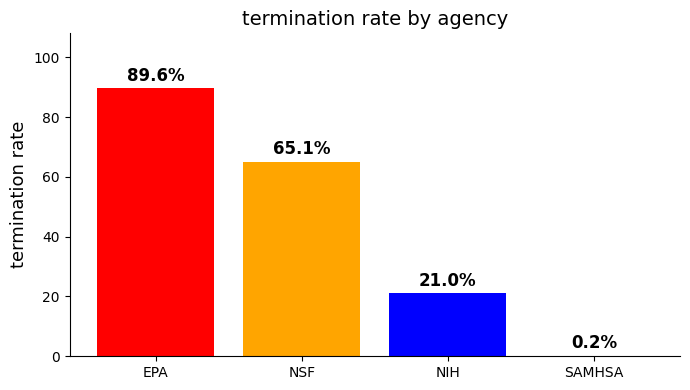

In [82]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(agency_stats.index, agency_stats['term_rate'] * 100, color=[AGENCY_COLORS.get(a, '#888') for a in agency_stats.index])
ax.set_ylabel('termination rate', fontsize=13)
ax.set_title('termination rate by agency', fontsize=14)
for bar, val in zip(bars, agency_stats['term_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
            f'{val:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, 108)
sns.despine()
plt.tight_layout(); plt.show()

### Agency classifier

In [83]:
X_ag_tr = pd.get_dummies(df_train['agency'], drop_first=False).fillna(0).astype(float)
X_ag_te = pd.get_dummies(df_test['agency'], drop_first=False).fillna(0).astype(float)
X_ag_te = X_ag_te.reindex(columns=X_ag_tr.columns, fill_value=0)
y_ag_tr = df_train['target_adverse'].fillna(0).values
y_ag_te = df_test['target_adverse'].fillna(0).values

In [84]:
clf_ag = LogisticRegression(max_iter=1000, class_weight='balanced')
cv_ag = cv(clf_ag, X_ag_tr, y_ag_tr, cv=skf, scoring=['roc_auc', 'average_precision'], return_train_score=False)
clf_ag.fit(X_ag_tr, y_ag_tr)
y_prob_ag = clf_ag.predict_proba(X_ag_te)[:, 1]
test_auc_ag = roc_auc_score(y_ag_te, y_prob_ag)
test_aucpr_ag = average_precision_score(y_ag_te, y_prob_ag)

TypeError: 'dict' object is not callable

In [ ]:
print(f'cv roc auc {cv_ag["test_roc_auc"].mean():.4f} ± {cv_ag["test_roc_auc"].std():.4f}')
print(f'cv auc pr {cv_ag["test_average_precision"].mean():.4f} ± {cv_ag["test_average_precision"].std():.4f}')
print(f'test roc auc {test_auc_ag:.4f}')
print(f'test auc pr {test_aucpr_ag:.4f}')

models with auc > this auc are capturing actual signal

### Terminated vs surviving

In [127]:
af = set(df_all_common.columns)
df = df_all_common.dropna(subset=['target_adverse']).copy()
y = df['target_adverse']
n1, n0 = int(_y.sum()), int((_y == 0).sum())

NameError: name '_y' is not defined

In [128]:
def bin_row(col, label):
    if col not in af: return None
    p1, p0 = df.loc[y==1, col].mean(), df.loc[y==0, col].mean()
    rr = p1 / p0 if p0 > 0 else float('nan')
    return {'feature': label,
            'terminated': f'{p1*100:.1f}%', 'surviving': f'{p0*100:.1f}%',
            'delta': f'{(p1-p0)*100:+.1f}pp', 'effect': f'RR={rr:.2f}'}

def count_row(col, label, fmt='.2f'):
    if col not in af: return None
    g1, g0 = df.loc[y==1, col].dropna(), df.loc[y==0, col].dropna()
    sd = np.sqrt((g1.std()**2 + g0.std()**2) / 2)
    d = (g1.mean() - g0.mean()) / sd if sd > 0 else float('nan')
    return {'feature': label,
            'terminated': f'{g1.mean():{fmt}}', 'surviving': f'{g0.mean():{fmt}}',
            'delta': f'{g1.mean()-g0.mean():+{fmt}}', 'effect': f'd={d:.2f}'}

In [87]:
rows = [
    bin_row('has_flagged_word_total', 'has any banned word'),
    count_row('num_flagged_words_total', 'banned word count (mean)'),
    count_row('n_banned_terms_total', 'banned term count (mean)'),
    count_row('award_amount', 'award amount usd', '.0f'),
    count_row('log_total_award', 'log award amount'),
    count_row('text_len', 'abstract word count', '.0f'),
]

rows = [r for r in rows if r is not None]
df_contrast = pd.DataFrame(rows)
df_contrast

,feature,terminated,surviving,delta,effect
0,has any banned word,92.4%,86.9%,+5.5pp,RR=1.06
1,award amount usd,9260937,2751398,+6509539,d=0.05
2,log award amount,13.44,14.00,-0.56,d=-0.38
3,abstract word count,414,408,+5,d=0.05


In [88]:
if 'org_state' in af:
    ss = (df.groupby('org_state')['target_adverse'].agg(n='count', n_term='sum', rate='mean').query('n >= 20').sort_values('rate', ascending=False).head(10))

    ss['rate'] = ss['rate'].round(3)
    ss

In [90]:
ic = next((c for c in ['org_name', 'organization_name', 'org_city'] if c in af), None)
if ic:
    iss = (df.groupby(ic)['target_adverse'].agg(n='count', n_term='sum', rate='mean').query('n >= 10').sort_values('rate', ascending=False).head(10))

    iss['rate'] = iss['rate'].round(3)
    iss

In [91]:
q2a_results = {'contrast_table': df_contrast.to_dict(orient='records')}

### Within agency

In [92]:
wa_results = []

for agency in ['EPA', 'NIH', 'NSF', 'SAMHSA']:
    df_ag_tr = df_abl_train[df_abl_train['agency'] == agency]
    df_ag_te = df_abl_test[df_abl_test['agency']   == agency]
    y_ag_tr = df_ag_tr['target_adverse'].values
    y_ag_te = df_ag_te['target_adverse'].values
    n_pos = int(y_ag_tr.sum())
    n_neg = int((y_ag_tr == 0).sum())

    print(f'{agency} train {len(y_ag_tr)} ({n_pos} pos vs {n_neg} neg)  '
          f'test {len(y_ag_te)} ({int(y_ag_te.sum())} pos)')

    if n_pos < 5 or n_neg < 5 or len(y_ag_te) < 5:
        print('skip bc less than 5 examples')
        continue

    n_splits = min(5, n_pos)
    skf_ag = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for cond_name, (num_c, cat_c) in [
        ('Text only',   ([], [])),
        ('Text + Meta', (all_meta_num, all_meta_cat)),
    ]:
        pipe = make_ablation_pipeline(num_c, cat_c, include_text=True)
        cv = cross_validate(pipe, df_ag_tr[input_cols], y_ag_tr, cv=skf_ag,
                            scoring=['roc_auc', 'average_precision'],
                            return_train_score=False)
        pipe.fit(df_ag_tr[input_cols], y_ag_tr)

        has_both = y_ag_te.sum() >= 2 and (y_ag_te == 0).sum() >= 2
        if has_both:
            y_prob = pipe.predict_proba(df_ag_te[input_cols])[:, 1]
            test_auc = round(roc_auc_score(y_ag_te, y_prob), 4)
            test_aucpr = round(average_precision_score(y_ag_te, y_prob), 4)
        else:
            test_auc = test_aucpr = float('nan')

        wa_results.append({
            'agency': agency, 'condition': cond_name,
            'n_train': len(y_ag_tr), 'pos_rate': round(float(y_ag_tr.mean()), 3),
            'cv_auc': round(float(cv['test_roc_auc'].mean()), 4),
            'cv_auc_std': round(float(cv['test_roc_auc'].std()), 4),
            'cv_aucpr': round(float(cv['test_average_precision'].mean()), 4),
            'test_auc': test_auc, 'test_aucpr': test_aucpr,
        })
        print(f'   {cond_name:<14}  CV AUC {cv["test_roc_auc"].mean():.4f}±{cv["test_roc_auc"].std():.4f}'
              f'  Test AUC {test_auc:.4f}  AUC-PR {test_aucpr:.4f}')

df_wa = pd.DataFrame(wa_results)

NameError: name 'df_abl_train' is not defined

In [ ]:
pivot = df_wa.pivot(index='agency', columns='condition', values='cv_auc').round(4)
pivot

In [ ]:
cross_text_only = df_ablation.loc['Text only', 'test_auc']
cross_all_meta = df_ablation.loc['Text + all metadata', 'test_auc']
print(f'cross-agency (all data): text only = {cross_text_only:.4f}, text+Meta = {cross_all_meta:.4f}')

In [ ]:
sub = df_wa[df_wa['condition'] == 'Text only'].set_index('agency')
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(sub.index, sub['cv_auc'],
              color=[AGENCY_COLORS.get(a, '#888') for a in sub.index],
              alpha=0.85, zorder=3)
if cross_text_only is not None:
    ax.axhline(cross_text_only, color='#374151', linestyle='--', linewidth=1.6,
               label=f'Cross agency ({cross_text_only:.3f})', zorder=4)
for bar, val in zip(bars, sub['cv_auc']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('cv roc auc (within agency)', fontsize=12)
ax.set_title('within-agency TF-IDF + LR - Text only', fontsize=13)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout(); plt.show()

### Proper noun strip


In [ ]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'lemmatizer'])


In [ ]:
nlp.max_length = 5_000_000


In [ ]:
ner_stopwords = {
    'r01','r21','r00','k99','u01','p01','r03','r15','r25','r34','r35','u54','r37',
    'nih','epa','nsf','samhsa','hhs','cdc',
}

phrases = [
    'specific aims', 'project summary', 'project narrative',
    'public health relevance', 'principal investigator', 'co-investigator',
    'national institutes of health', 'environmental protection agency',
    'national science foundation',
    'substance abuse and mental health services administration',
]

phrase_re = re.compile(r'\b(' + '|'.join(re.escape(p) for p in phrases) + r')\b', re.IGNORECASE)

In [ ]:
def strip_texts(texts, batch_size=64):
    out = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        spans = sorted(
            [(e.start_char, e.end_char)
             for e in doc.ents if e.label_ in {'ORG', 'GPE'}],
            reverse=True,
        )
        text = doc.text
        for s, e in spans:
            text = text[:s] + ' ' + text[e:]
        text = phrase_re.sub(' ', text)
        tokens = text.lower().split()
        out.append(' '.join(t for t in tokens if t not in ner_stopwords))
    return out

In [ ]:
if 'all_text_clean' not in df_all_common.columns:
    raw_texts = (df_all_common['project_title'].fillna('') + ' ' + df_all_common['abstract'].fillna('')).tolist()
    df_all_common['all_text_clean'] = strip_texts(raw_texts)
    orig_len = df_all_common['all_text'].str.split().str.len().mean()
    clean_len = df_all_common['all_text_clean'].str.split().str.len().mean()
    print(f'mean tokens {orig_len:.0f} -> {clean_len:.0f}  '
          f'({orig_len - clean_len:.0f} = {(orig_len-clean_len)/orig_len:.1%})')
else:
    print('all_text_clean already computed, skipping.')

df_train['all_text_clean'] = df_all_common.loc[df_train.index, 'all_text_clean']
df_test['all_text_clean']  = df_all_common.loc[df_test.index,  'all_text_clean']

In [ ]:
def make_clean_pipe(num_cols, cat_cols, include_text=True):
    transformers = []
    if include_text:
        transformers.append(
            ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                                      sublinear_tf=True, stop_words='english'),
             'all_text_clean')
        )
    if num_cols:
        transformers.append(
            ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols)
        )
    if cat_cols:
        transformers.append(
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        )
    pre = ColumnTransformer(transformers, remainder='drop', sparse_threshold=0)
    return Pipeline([
        ('pre', pre),
        ('lr',  LogisticRegression(penalty='l2', solver='lbfgs',
                                   max_iter=5000, class_weight='balanced')),
    ])

In [ ]:
clean_results = []
for cond_name, (num_c, cat_c) in [
    ('Text only', ([], [])),
    ('Text + all meta', (all_meta_num, all_meta_cat)),
]:
    pipe = _make_clean_pipe(num_c, cat_c, include_text=True)
    cv = cross_validate(pipe, df_abl_tr_cl[input_cols_clean],
                        df_abl_tr_cl['target_adverse'].values, cv=skf,
                        scoring=['roc_auc', 'average_precision'],
                        return_train_score=False)
    pipe.fit(df_abl_tr_cl[input_cols_clean], df_abl_tr_cl['target_adverse'].values)
    y_prob = pipe.predict_proba(df_abl_te_cl[input_cols_clean])[:, 1]
    test_auc = roc_auc_score(df_abl_te_cl['target_adverse'].values, y_prob)
    test_aucpr = average_precision_score(df_abl_te_cl['target_adverse'].values, y_prob)
    clean_results.append({
        'condition': cond_name,
        'cv_auc_clean': round(float(cv['test_roc_auc'].mean()), 4),
        'cv_aucpr_clean': round(float(cv['test_average_precision'].mean()), 4),
        'test_auc_clean': round(test_auc, 4),
        'test_aucpr_clean': round(test_aucpr, 4),
    })
    print(f'{cond_name:<20}  cv auc {cv["test_roc_auc"].mean():.4f}  '
          f'test auc {test_auc:.4f}  auc pr {test_aucpr:.4f}')

df_clean = pd.DataFrame(clean_results).set_index('condition')

before and after

In [ ]:
cond_map = {
    'Text only':       'Text only',
    'Text + all meta': 'Text + all metadata',
}

In [ ]:
rows_ba = []
for clean_cond, raw_cond in COND_MAP.items():
    try:
        raw_auc = df_ablation.loc[raw_cond, 'test_auc']
        raw_aucpr = df_ablation.loc[raw_cond, 'test_aucpr']
    except Exception:
        raw_auc = raw_aucpr = float('nan')
    rows_ba.append({
        'condition': clean_cond,
        'Raw auc': raw_auc,
        'Clean auc': df_clean.loc[clean_cond, 'test_auc_clean'],
        'delta auc': round(df_clean.loc[clean_cond, 'test_auc_clean'] - raw_auc, 4),
        'raw auc pr':   raw_aucpr,
        'clean auc pr': df_clean.loc[clean_cond, 'test_aucpr_clean'],
        'delta auc pr':      round(df_clean.loc[clean_cond, 'test_aucpr_clean'] - raw_aucpr, 4),
    })

df_ba = pd.DataFrame(rows_ba).set_index('Condition').round(4)
df_ba

negative delta - drop could be identitiy leakage

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, raw_col, clean_col in [
    (axes[0], 'roc auc', 'raw auc', 'clean auc'),
    (axes[1], 'auc pr', 'raw auc pr', 'clean auc pr'),
]:
    x = np.arange(len(df_ba))
    w = 0.35
    ax.bar(x - w/2, df_ba[raw_col],   width=w, label='Raw',   color='#3B82F6', alpha=0.85)
    ax.bar(x + w/2, df_ba[clean_col], width=w, label='Clean', color='#9CA3AF', alpha=0.85)
    for xi, (rv, cv_) in enumerate(zip(df_ba[raw_col], df_ba[clean_col])):
        ax.text(xi - w/2, rv   + 0.008, f'{rv:.3f}',   ha='center', fontsize=10)
        ax.text(xi + w/2, cv_ + 0.008, f'{cv_:.3f}',  ha='center', fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(df_ba.index, fontsize=11)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'tf idf {metric} raw vs ner clean', fontsize=12)
    ax.set_ylim(0, 1.08)
    ax.legend(fontsize=11)
    sns.despine(ax=ax)
plt.suptitle('identity leakage: ner + boilerplate strip', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### SHAP

In [130]:
inst_cat = []


In [133]:
# all_meta_num = financial_cols + keyword_cols + temporal_cols + text_prop_cols
all_meta_num = financial + keyword + temporal + text_props
all_meta_cat = inst_cat

In [134]:
num_cols_b6 = all_meta_num
cat_cols_b6 = all_meta_cat   # institutional
req_b6 = num_cols_b6 + cat_cols_b6 + embed_cols + ['target_adverse']

df_b6_train = df_train.dropna(subset=req_b6)
df_b6_test = df_test.dropna(subset=req_b6)

meta_pre_b6 = ColumnTransformer(
    num_preprocessor(num_cols_b6) +
    ([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_b6)] if cat_cols_b6 else []),
    remainder='drop'
)

meta_train = meta_pre_b6.fit_transform(df_b6_train[num_cols_b6 + cat_cols_b6])
meta_test = meta_pre_b6.transform(df_b6_test[num_cols_b6 + cat_cols_b6])

In [135]:
TOP_K = 20
RNG = np.random.RandomState(42)

def bg(X, n=300):
    idx = RNG.choice(X.shape[0], min(n, X.shape[0]), replace=False)
    return X[idx]

def clean(n):
    return n.replace('tfidf__', '').replace('num__', '').replace('cat__', '')

#### TF IDF + LR

In [137]:
X_shap_tr = df_abl_train[input_cols]
X_shap_te = df_abl_test[input_cols]
y_shap_tr = df_abl_train['target_adverse'].values

shap_pipes = {
    'Text only': make_ablation_pipeline([], [], include_text=True),
    'Text + Meta': make_ablation_pipeline(all_meta_num, [], include_text=True),
}

sv_store, fn_store = {}, {}

for cond, pipe in shap_pipes.items():
    pipe.fit(X_shap_tr, y_shap_tr)
    pre = pipe.named_steps['pre']
    lr = pipe.named_steps['lr']

    X_tr_t = pre.transform(X_shap_tr)
    X_te_t = pre.transform(X_shap_te)

    feat_names = np.array(pre.get_feature_names_out())

    explainer = shap.LinearExplainer(lr, bg(X_tr_t))
    sv_store[cond] = explainer.shap_values(X_te_t)
    fn_store[cond] = feat_names
    print(f"  {cond:<14} - {feat_names.shape[0]:,} features")

  Text only      - 10,000 features


  Text + Meta    - 10,018 features


top tokens (text only)

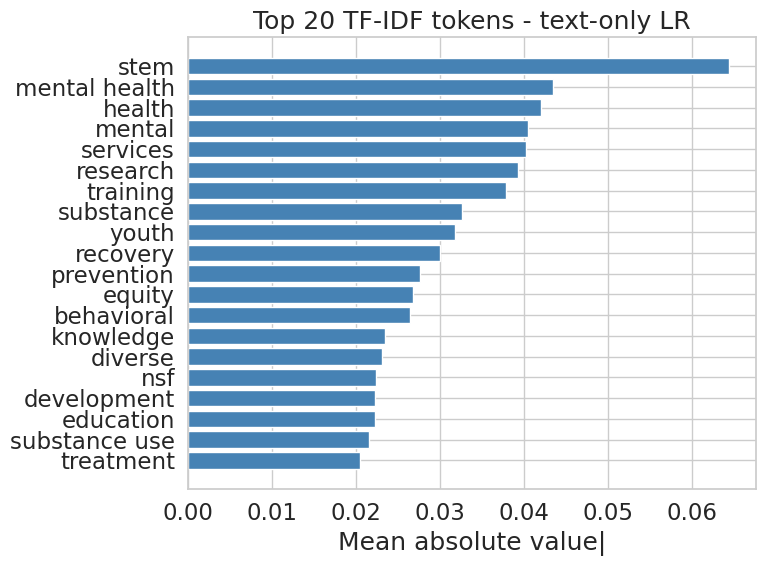

In [138]:
sv_to = sv_store['Text only']
fn_to = fn_store['Text only']
mean_to = np.abs(sv_to).mean(axis=0)
top_to = np.argsort(mean_to)[-TOP_K:][::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    [clean(fn_to[i]) for i in top_to][::-1],
    mean_to[top_to][::-1], color='steelblue'
)
ax.set_xlabel('Mean absolute value|')
ax.set_title(f'Top {TOP_K} TF-IDF tokens - text-only LR')
plt.tight_layout(); plt.show()

text + meta

In [141]:
import matplotlib.patches as mpatches


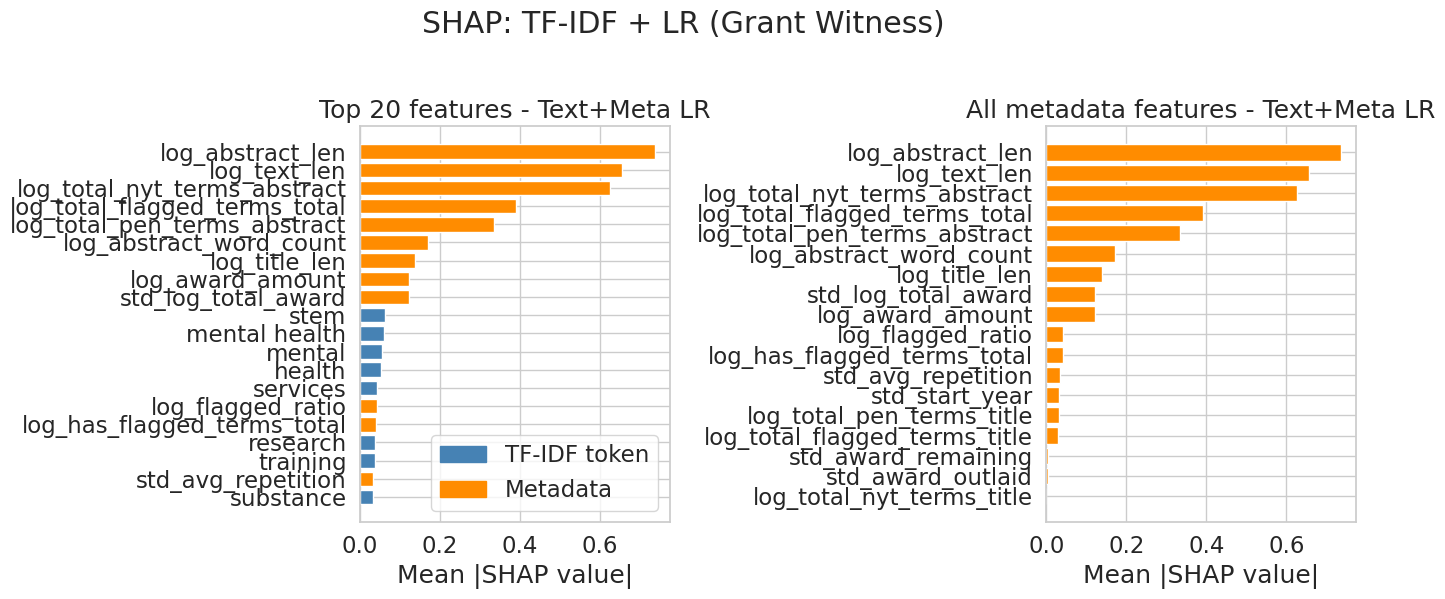

In [143]:
sv_tm = sv_store['Text + Meta']
fn_tm = fn_store['Text + Meta']
mean_tm = np.abs(sv_tm).mean(axis=0)

is_text = np.array([n.startswith('tfidf__') for n in fn_tm])
is_meta = ~is_text

top_tm = np.argsort(mean_tm)[-TOP_K:][::-1]
colors = ['steelblue' if is_text[i] else 'darkorange' for i in top_tm]

meta_names_tm = fn_tm[is_meta]
meta_shap_tm = mean_tm[is_meta]
meta_ord_tm = np.argsort(meta_shap_tm)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(
    [clean(fn_tm[i]) for i in top_tm][::-1],
    mean_tm[top_tm][::-1], color=colors[::-1]
)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title(f'Top {TOP_K} features - Text+Meta LR')
axes[0].legend(handles=[
    mpatches.Patch(color='steelblue',  label='TF-IDF token'),
    mpatches.Patch(color='darkorange', label='Metadata'),
], loc='lower right')

axes[1].barh(
    [clean(n) for n in meta_names_tm[meta_ord_tm]][::-1],
    meta_shap_tm[meta_ord_tm][::-1], color='darkorange'
)
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('All metadata features - Text+Meta LR')

plt.suptitle('SHAP: TF-IDF + LR (Grant Witness)', y=1.01)
plt.tight_layout(); plt.show()


group level attribution

In [147]:
text_c = mean_tm[is_text].sum()
meta_c = mean_tm[is_meta].sum()
total_tm = text_c + meta_c

print(f"  Text (TF-IDF tokens) {text_c:.4f}  ({text_c/total_tm*100:.1f}%)")
print(f"  Metadata features:    {meta_c:.4f}  ({meta_c/total_tm*100:.1f}%)")
print(f"  Metadata by feature:")
for i in meta_ord_tm:
    print(f"    {clean(meta_names_tm[i]):<40s}  {meta_shap_tm[i]:.5f}")

lr_emb = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000, class_weight='balanced')
lr_emb.fit(X_b6_train, y_b6_train)

explainer_emb = shap.LinearExplainer(lr_emb, bg(X_b6_train))
sv_emb = explainer_emb.shap_values(X_b6_test)

n_emb_dims = embed_train.shape[1]
is_emb_feat = np.array([True]  * n_emb_dims + [False] * meta_train.shape[1])
is_meta_b6 = ~is_emb_feat
meta_names_b6 = np.array([clean(n) for n in meta_pre_b6.get_feature_names_out()])
mean_sv_emb = np.abs(sv_emb).mean(axis=0)

emb_c_b6 = mean_sv_emb[is_emb_feat].sum()
meta_c_b6 = mean_sv_emb[is_meta_b6].sum()
total_b6 = emb_c_b6 + meta_c_b6

print(f"  Embeddings ({n_emb_dims} dims) {emb_c_b6:.4f}  ({emb_c_b6/total_b6*100:.1f}%)")
print(f"  Metadata features:       {meta_c_b6:.4f}  ({meta_c_b6/total_b6*100:.1f}%)")

meta_shap_b6 = mean_sv_emb[is_meta_b6]
meta_ord_b6 = np.argsort(meta_shap_b6)[::-1]

  Text (TF-IDF tokens) 6.8031  (65.9%)
  Metadata features:    3.5181  (34.1%)
  Metadata by feature:
    log_abstract_len                          0.73754
    log_text_len                              0.65592
    log_total_nyt_terms_abstract              0.62617
    log_total_flagged_terms_total             0.39113
    log_total_pen_terms_abstract              0.33434
    log_abstract_word_count                   0.17091
    log_title_len                             0.13808
    std_log_total_award                       0.12203
    log_award_amount                          0.12203
    log_flagged_ratio                         0.04222
    log_has_flagged_terms_total               0.04149
    std_avg_repetition                        0.03364
    std_start_year                            0.03216
    log_total_pen_terms_title                 0.03093
    log_total_flagged_terms_title             0.02902
    std_award_remaining                       0.00528
    std_award_outlaid             

  Embeddings (1536 dims) 10.9509  (74.6%)
  Metadata features:       3.7227  (25.4%)


group comparison (embeddings)

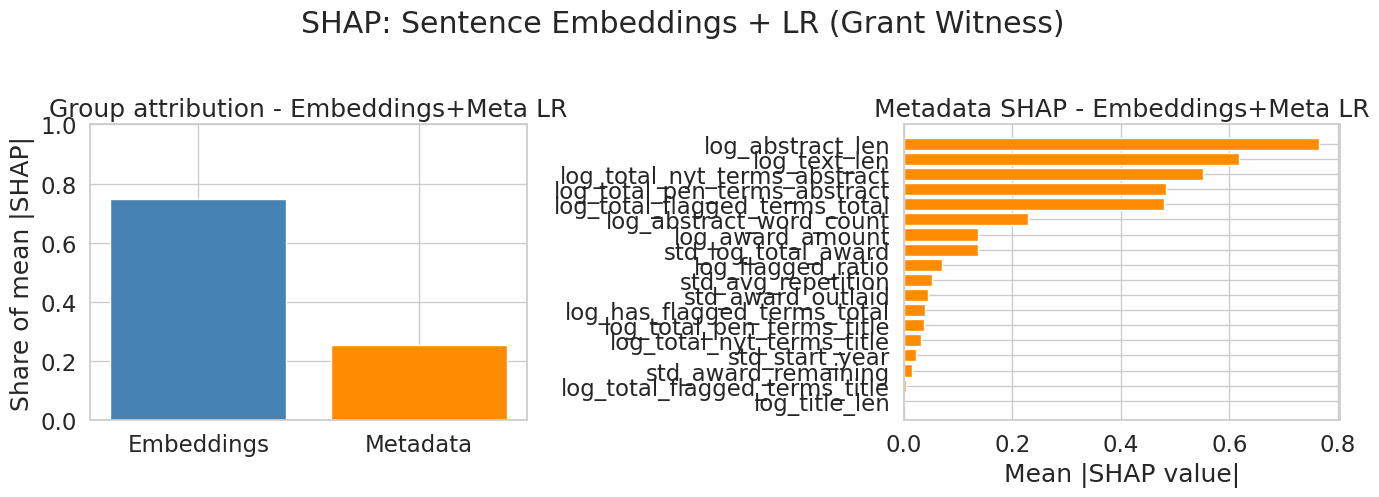

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    ['Embeddings', 'Metadata'],
    [emb_c_b6 / total_b6, meta_c_b6 / total_b6],
    color=['steelblue', 'darkorange']
)
axes[0].set_ylabel('Share of mean |SHAP|')
axes[0].set_title('Group attribution - Embeddings+Meta LR')
axes[0].set_ylim(0, 1)

axes[1].barh(
    meta_names_b6[meta_ord_b6][::-1],
    meta_shap_b6[meta_ord_b6][::-1], color='darkorange'
)
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('Metadata SHAP - Embeddings+Meta LR')

plt.suptitle('SHAP: Sentence Embeddings + LR (Grant Witness)', y=1.01)
plt.tight_layout(); plt.show()

does metadata improve over text only?>+

In [149]:
print(f"TF-IDF + Meta: metadata = {meta_c/total_tm*100:.1f}% of mean |SHAP| mass")
print(f"Emb + Meta: metadata = {meta_c_b6/total_b6*100:.1f}% of mean |SHAP| mass")

TF-IDF + Meta: metadata = 34.1% of mean |SHAP| mass
Emb + Meta: metadata = 25.4% of mean |SHAP| mass


#### IN SEABORN

In [150]:
sns.set_theme(style='whitegrid', font_scale=1.5)


In [174]:
# SHAP with institutional columns included
shap_pipes = {
    'Text only': make_ablation_pipeline([], [], include_text=True),
    'Text + Meta': make_ablation_pipeline(all_meta_num, inst_cat, include_text=True),
}

sv_store, fn_store = {}, {}

for cond, pipe in shap_pipes.items():
    pipe.fit(X_shap_tr, y_shap_tr)
    pre = pipe.named_steps['pre']
    lr = pipe.named_steps['lr']

    X_tr_t = pre.transform(X_shap_tr)
    X_te_t = pre.transform(X_shap_te)

    feat_names = np.array(pre.get_feature_names_out())

    explainer = shap.LinearExplainer(lr, bg(X_tr_t))
    sv_store[cond] = explainer.shap_values(X_te_t)
    fn_store[cond] = feat_names

    print(f"{cond:<14} - {feat_names.shape[0]:,} features")

Text only      - 10,000 features


Text + Meta    - 10,018 features


In [176]:
pipe_noinst = make_ablation_pipeline(all_meta_num, inst_cat, include_text=True)
pipe_noinst.fit(X_shap_tr, y_shap_tr)

pre_noinst = pipe_noinst.named_steps['pre']
lr_noinst = pipe_noinst.named_steps['lr']

X_tr_ni = pre_noinst.transform(X_shap_tr)
X_te_ni = pre_noinst.transform(X_shap_te)
fn_tm_g = np.array(pre_noinst.get_feature_names_out())

explainer_ni = shap.LinearExplainer(lr_noinst, bg(X_tr_ni))
sv_tm_g = explainer_ni.shap_values(X_te_ni)

In [177]:
# Group setup for seaborn SHAP plot
sns.set_theme(style='whitegrid', font_scale=1.5)

group_order = [
    'Text',
    'Keyword risk',
    'Financial',
    'Temporal',
    'Text properties',
    'Institutional',
]


group_colors = {
    'Text': 'steelblue',
    'Keyword risk': 'firebrick',
    'Financial': 'cornflowerblue',
    'Temporal': 'darkslateblue',
    'Institutional': 'deeppink',
    'Text properties': 'mediumpurple',
}

group_cols = [
    ('Keyword risk', keyword),
    ('Financial', financial),
    ('Temporal', temporal),
    ('Text properties', text_props),
    ('Institutional', inst_cat),
]

def assign_group(feat_name):
    if feat_name.startswith('tfidf__'):
        return 'Text'

    bare = feat_name.split('__', 1)[-1] if '__' in feat_name else feat_name

    for group, cols in group_cols:
        for col in cols:
            if bare == col or bare.startswith(col + '_'):
                return group

    return 'Other'

without org_state

In [166]:
pipe_noinst = make_ablation_pipeline(all_meta_num, inst_cat, include_text=True)
pipe_noinst.fit(X_shap_tr, y_shap_tr)
pre_noinst = pipe_noinst.named_steps['pre']
lr_noinst  = pipe_noinst.named_steps['lr']

X_tr_ni = pre_noinst.transform(X_shap_tr)
X_te_ni = pre_noinst.transform(X_shap_te)
fn_tm_g = np.array(pre_noinst.get_feature_names_out())

explainer_ni = shap.LinearExplainer(lr_noinst, bg(X_tr_ni))
sv_tm_g = explainer_ni.shap_values(X_te_ni)

plot setup

In [167]:
sns.set_theme(style='whitegrid', font_scale=1.5)

group_order = [
    'Text',
    'Keyword risk',
    'Financial',
    'Temporal',
    'Institutional',
    'Text properties',
]

group_colors = {
    'Text': 'steelblue',
    'Keyword risk': 'firebrick',
    'Financial': 'cornflowerblue',
    'Temporal': 'darkslateblue',
    'Institutional': 'deeppink',
    'Text properties': 'mediumpurple',
}

group_cols = [
    ('Keyword risk', keyword),
    ('Financial', financial),
    ('Temporal', temporal),
    ('Institutional', inst_cat),
    ('Text properties', text_props),
]

def assign_group(feat_name):
    if feat_name.startswith('tfidf__'):
        return 'Text'
    bare = feat_name.split('__', 1)[-1] if '__' in feat_name else feat_name
    for group, cols in group_cols:
        for col in cols:
            if bare == col or bare.startswith(col + '_'):
                return group
    return 'Other'

aggregate tf idf shap

In [178]:
mean_tm_g = np.abs(sv_tm_g).mean(axis=0)
group_totals_tm = {}
for feat, val in zip(fn_tm_g, mean_tm_g):
    g = assign_group(feat)
    group_totals_tm[g] = group_totals_tm.get(g, 0.0) + val
total_tm_g = sum(group_totals_tm.values())
pct_tm = {g: v / total_tm_g * 100 for g, v in group_totals_tm.items()}

aggregate embeddings shap (no org_state)

In [179]:
mean_sv_emb_g  = np.abs(sv_emb).mean(axis=0)
meta_fnames_b6 = meta_pre_b6.get_feature_names_out()

group_totals_b6 = {'Text': mean_sv_emb_g[:n_emb_dims].sum()}
for feat, val in zip(meta_fnames_b6, mean_sv_emb_g[n_emb_dims:]):
    g = assign_group(feat)
    if g == 'Other':
        continue
    group_totals_b6[g] = group_totals_b6.get(g, 0.0) + val
total_b6_g = sum(group_totals_b6.values())
pct_b6 = {g: v / total_b6_g * 100 for g, v in group_totals_b6.items()}


In [180]:
rows = []
for g in group_order:
    if g in pct_tm:
        rows.append({'Group': g, 'Model': 'TF-IDF + LR', 'pct': pct_tm[g]})
    if g in pct_b6:
        rows.append({'Group': g, 'Model': 'Embeddings + LR', 'pct': pct_b6[g]})
df_shap_grouped = pd.DataFrame(rows)

In [181]:
text_labels = {
    'TF-IDF + LR': 'TF-IDF',
    'Embeddings + LR': 'Embeddings',
}
model_titles = {
    'TF-IDF + LR': 'TF-IDF + Meta LR',
    'Embeddings + LR': 'Embeddings + Meta  LR',
}

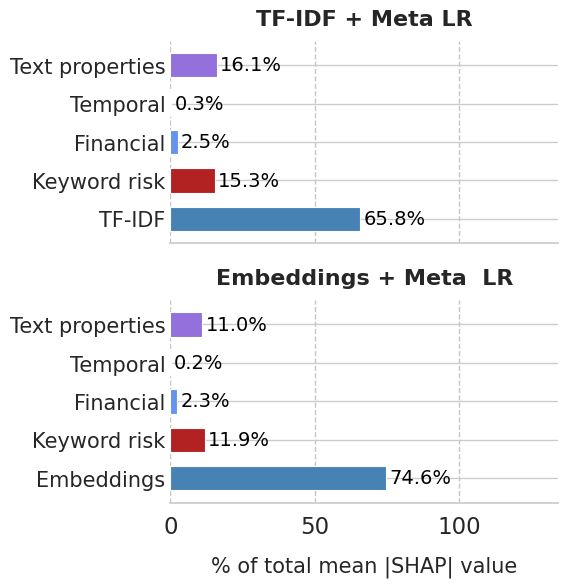

In [182]:
global_max = df_shap_grouped['pct'].max()

fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex=True)
plt.subplots_adjust(hspace=0.28)

for ax, model in zip(axes, ['TF-IDF + LR', 'Embeddings + LR']):
    sub = df_shap_grouped[df_shap_grouped['Model'] == model].copy()
    sub = sub.set_index('Group').reindex(group_order).dropna().reset_index()

    display_labels = [
        text_labels[model] if g == 'Text' else g
        for g in sub['Group']
    ]
    colors = [group_colors[g] for g in sub['Group']]
    vals   = sub['pct'].values
    y_pos  = np.arange(len(vals)) * 0.55

    bars = ax.barh(y_pos, vals, color=colors, height=0.35,
                   edgecolor='white', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(display_labels, fontsize=15)
    ax.set_title(model_titles[model], fontsize=16, fontweight='bold', pad=11)
    ax.tick_params(axis='y', length=0)
    ax.xaxis.grid(True, linestyle='--', alpha=0.45, color='grey')
    ax.set_axisbelow(True)
    ax.set_xlim(0, global_max * 1.8)
    ax.set_ylim(-0.35, (len(vals) - 1) * 0.55 + 0.35)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_width() + global_max * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%',
            va='center', ha='left', fontsize=14, color='black',
            fontweight='medium'
        )
    sns.despine(ax=ax, left=True, bottom=False)

axes[1].set_xlabel('% of total mean |SHAP| value', labelpad=12, fontsize=15)
plt.show()


In [183]:
# Standalone SHAP section with institutional columns included
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

TOP_K_INST = 20
RNG_INST = np.random.RandomState(42)

def bg_inst(X, n=300):
    idx = RNG_INST.choice(X.shape[0], min(n, X.shape[0]), replace=False)
    return X[idx]

def clean_inst(name):
    return (
        str(name)
        .replace('tfidf__', '')
        .replace('log_num__', '')
        .replace('std_num__', '')
        .replace('bin_num__', '')
        .replace('cat__', '')
        .replace('num__', '')
    )

# Prefer an explicit inst_col if you defined one elsewhere; otherwise default to org_state.
if 'inst_col' in globals():
    inst_cols_shap = list(inst_col)
elif 'inst_cat' in globals() and len(inst_cat) > 0:
    inst_cols_shap = list(inst_cat)
else:
    inst_cols_shap = ['org_state']

meta_num_shap = list(dict.fromkeys(financial + keyword + temporal + text_props))
meta_cat_shap = [c for c in inst_cols_shap if c in df_train.columns]
meta_num_shap = [c for c in meta_num_shap if c in df_train.columns]

input_cols_shap = ['all_text'] + meta_num_shap + meta_cat_shap
req_shap = input_cols_shap + ['target_adverse']

df_shap_train_inst = df_train.dropna(subset=req_shap).copy()
df_shap_test_inst = df_test.dropna(subset=req_shap).copy()
y_shap_train_inst = df_shap_train_inst['target_adverse'].values

print('Institutional columns:', meta_cat_shap)
print(f'TF-IDF SHAP train {len(df_shap_train_inst):,}, test {len(df_shap_test_inst):,}')


Institutional columns: ['org_state']
TF-IDF SHAP train 5,761, test 1,431


In [184]:
# TF-IDF + metadata LR SHAP, including institutional categorical columns
shap_pipes_inst = {
    'Text only': make_ablation_pipeline([], [], include_text=True),
    'Text + Meta': make_ablation_pipeline(meta_num_shap, meta_cat_shap, include_text=True),
}

sv_store_inst, fn_store_inst = {}, {}

for cond, pipe in shap_pipes_inst.items():
    pipe.fit(df_shap_train_inst[input_cols_shap], y_shap_train_inst)
    pre = pipe.named_steps['pre']
    lr = pipe.named_steps['lr']

    X_tr_t = pre.transform(df_shap_train_inst[input_cols_shap])
    X_te_t = pre.transform(df_shap_test_inst[input_cols_shap])
    feat_names = np.array(pre.get_feature_names_out())

    explainer = shap.LinearExplainer(lr, bg_inst(X_tr_t))
    sv_store_inst[cond] = explainer.shap_values(X_te_t)
    fn_store_inst[cond] = feat_names

    print(f'{cond:<14} - {feat_names.shape[0]:,} features')

sv_tm_inst = sv_store_inst['Text + Meta']
fn_tm_inst = fn_store_inst['Text + Meta']
mean_tm_inst = np.abs(sv_tm_inst).mean(axis=0)


Text only      - 10,000 features


Text + Meta    - 10,077 features


In [185]:
# Embeddings + metadata LR SHAP, including institutional categorical columns
req_emb_inst = meta_num_shap + meta_cat_shap + embed_cols + ['target_adverse']
df_emb_train_inst = df_train.dropna(subset=req_emb_inst).copy()
df_emb_test_inst = df_test.dropna(subset=req_emb_inst).copy()

meta_pre_inst = ColumnTransformer(
    num_preprocessor(meta_num_shap) +
    ([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), meta_cat_shap)] if meta_cat_shap else []),
    remainder='drop'
)

meta_train_inst = meta_pre_inst.fit_transform(df_emb_train_inst[meta_num_shap + meta_cat_shap])
meta_test_inst = meta_pre_inst.transform(df_emb_test_inst[meta_num_shap + meta_cat_shap])

embed_train_inst = parse_embed_matrix(df_emb_train_inst)
embed_test_inst = parse_embed_matrix(df_emb_test_inst)

X_emb_train_inst = np.hstack([embed_train_inst, meta_train_inst])
X_emb_test_inst = np.hstack([embed_test_inst, meta_test_inst])
y_emb_train_inst = df_emb_train_inst['target_adverse'].values

lr_emb_inst = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000, class_weight='balanced')
lr_emb_inst.fit(X_emb_train_inst, y_emb_train_inst)

explainer_emb_inst = shap.LinearExplainer(lr_emb_inst, bg_inst(X_emb_train_inst))
sv_emb_inst = explainer_emb_inst.shap_values(X_emb_test_inst)

n_emb_dims_inst = embed_train_inst.shape[1]
meta_fnames_emb_inst = np.array(meta_pre_inst.get_feature_names_out())
mean_emb_inst = np.abs(sv_emb_inst).mean(axis=0)

print(f'Embedding SHAP train {X_emb_train_inst.shape}, test {X_emb_test_inst.shape}')
print(f'Metadata features in embedding model: {len(meta_fnames_emb_inst):,}')


Embedding SHAP train (5761, 1613), test (1431, 1613)
Metadata features in embedding model: 77


In [186]:
# Group attribution setup
sns.set_theme(style='whitegrid', font_scale=1.5)

group_order_inst = [
    'Text',
    'Keyword risk',
    'Financial',
    'Temporal',
    'Institutional',
    'Text properties',
]

group_colors_inst = {
    'Text': 'steelblue',
    'Keyword risk': 'firebrick',
    'Financial': 'cornflowerblue',
    'Temporal': 'darkslateblue',
    'Institutional': 'deeppink',
    'Text properties': 'mediumpurple',
}

group_cols_inst = [
    ('Keyword risk', keyword),
    ('Financial', financial),
    ('Temporal', temporal),
    ('Institutional', meta_cat_shap),
    ('Text properties', text_props),
]

def assign_group_inst(feat_name):
    if str(feat_name).startswith('tfidf__'):
        return 'Text'

    bare = clean_inst(feat_name)
    for group, cols in group_cols_inst:
        for col in cols:
            if bare == col or bare.startswith(col + '_'):
                return group
    return 'Other'

def pct_by_group_inst(feature_names, mean_abs_shap):
    totals = {}
    for feat, val in zip(feature_names, mean_abs_shap):
        group = assign_group_inst(feat)
        if group == 'Other':
            continue
        totals[group] = totals.get(group, 0.0) + float(val)
    total = sum(totals.values())
    return {g: v / total * 100 for g, v in totals.items() if total > 0}


In [187]:
# Aggregate TF-IDF and embedding SHAP into comparable groups
pct_tfidf_inst = pct_by_group_inst(fn_tm_inst, mean_tm_inst)

emb_feature_names_inst = np.concatenate([
    np.array([f'embedding_{i}' for i in range(n_emb_dims_inst)]),
    meta_fnames_emb_inst,
])
emb_feature_names_inst[:n_emb_dims_inst] = 'tfidf__EMBEDDINGS'  # map embedding dimensions to Text group
pct_emb_inst = pct_by_group_inst(emb_feature_names_inst, mean_emb_inst)

rows_inst = []
for group in group_order_inst:
    if group in pct_tfidf_inst:
        rows_inst.append({'Group': group, 'Model': 'TF-IDF + LR', 'pct': pct_tfidf_inst[group]})
    if group in pct_emb_inst:
        rows_inst.append({'Group': group, 'Model': 'Embeddings + LR', 'pct': pct_emb_inst[group]})

df_shap_grouped_inst = pd.DataFrame(rows_inst)
df_shap_grouped_inst


,Group,Model,pct
0,Text,TF-IDF + LR,46.478228
1,Text,Embeddings + LR,58.685692
2,Keyword risk,TF-IDF + LR,9.825126
3,Keyword risk,Embeddings + LR,7.971515
4,Financial,TF-IDF + LR,4.326686
5,Financial,Embeddings + LR,3.829743
6,Temporal,TF-IDF + LR,1.998354
7,Temporal,Embeddings + LR,1.825305
8,Institutional,TF-IDF + LR,19.882113
9,Institutional,Embeddings + LR,16.460021


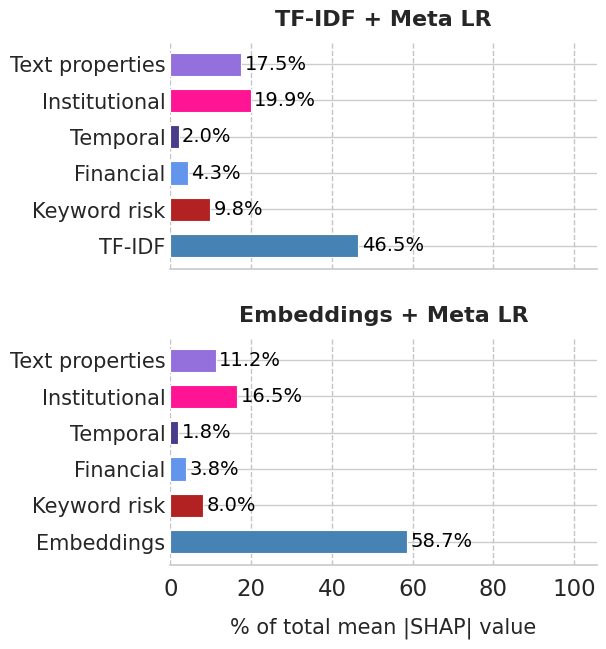

In [188]:
# Seaborn grouped SHAP plot with institutional metadata
text_labels_inst = {
    'TF-IDF + LR': 'TF-IDF',
    'Embeddings + LR': 'Embeddings',
}
model_titles_inst = {
    'TF-IDF + LR': 'TF-IDF + Meta LR',
    'Embeddings + LR': 'Embeddings + Meta LR',
}

global_max_inst = df_shap_grouped_inst['pct'].max()

fig, axes = plt.subplots(2, 1, figsize=(5.5, 6.8), sharex=True)
plt.subplots_adjust(hspace=0.30)

for ax, model in zip(axes, ['TF-IDF + LR', 'Embeddings + LR']):
    sub = df_shap_grouped_inst[df_shap_grouped_inst['Model'] == model].copy()
    sub = sub.set_index('Group').reindex(group_order_inst).dropna().reset_index()

    display_labels = [
        text_labels_inst[model] if g == 'Text' else g
        for g in sub['Group']
    ]
    colors = [group_colors_inst[g] for g in sub['Group']]
    vals = sub['pct'].values
    y_pos = np.arange(len(vals)) * 0.55

    bars = ax.barh(
        y_pos, vals, color=colors, height=0.35,
        edgecolor='white', linewidth=0.8
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(display_labels, fontsize=15)
    ax.set_title(model_titles_inst[model], fontsize=16, fontweight='bold', pad=11)
    ax.tick_params(axis='y', length=0)
    ax.xaxis.grid(True, linestyle='--', alpha=0.45, color='grey')
    ax.set_axisbelow(True)
    ax.set_xlim(0, global_max_inst * 1.8)
    ax.set_ylim(-0.35, (len(vals) - 1) * 0.55 + 0.35)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_width() + global_max_inst * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%',
            va='center', ha='left', fontsize=14,
            color='black', fontweight='medium'
        )
    sns.despine(ax=ax, left=True, bottom=False)

axes[1].set_xlabel('% of total mean |SHAP| value', labelpad=12, fontsize=15)
plt.show()
